### **Data**

[Transactions Data Bank ⛔||⛔ Fraud Detection](https://www.kaggle.com/datasets/qusaybtoush1990/transactions-data-bank-fraud-detection?resource=download)

### **Импорт библиотек**

In [ ]:
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# !pip install optuna catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 10.2 MB/s eta 0:00:00


In [ ]:
# !pip install pytorch_tabnet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.5/44.5 kB 2.1 MB/s eta 0:00:00


In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import display, Markdown, HTML
from datetime import datetime
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve, precision_recall_curve, f1_score, average_precision_score, accuracy_score, precision_score, recall_score, fbeta_score
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from catboost import CatBoostClassifier
import optuna
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from tqdm import tqdm
import matplotlib.pyplot as plt
from pytorch_tabnet.tab_model import TabNetClassifier
import mlflow
import mlflow.pytorch
import mlflow.sklearn
from mlflow.models import infer_signature
import os

c:\Users\Mi\Desktop\study\Search_for_anomalies_in_data\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### **Загрузка данных**

In [2]:
file_id = '1xoDH4u_CzwtpMNU3WA9-9VhwR7dZjaI4'  # из .../file/d/<ID>/view
url = f'https://drive.google.com/uc?export=download&id={file_id}'
df = pd.read_csv(url)

### **Описание датасета**

|Сolumn  | Description |
|------------|-------------|
|Date | Date of Transaction|
|nameOrig | User Name or Account number|
|amount | Money in this transaction|
|oldbalanceOrg | How much the client had money before transaction|
|newbalanceOrig | How much the client have after the transaction|
|City |where the transaction happened which city|
|type | Type of transaction TRANSFER \ CASH_OUT, CASH_IN ,DEBIT,PAYMENT|
|Card Type | The card type the client has \ Platinum ,Gold ,Silver ,Signature ,Classic ,Mass|
|Exp Type | The purpose for transaction \ Food, Entertainment, Fuel, Bills, Grocery, Travel, Personal_Care, Health_Fitness, Home|
|Gender |Male or Female|
|isFraud | 0 = no fraud, 1 = fraud|


In [3]:
df.head()

,Date,nameOrig,amount,oldbalanceOrg,newbalanceOrig,City,type,Card Type,Exp Type,Gender,isFraud
0,26-May-13,C2011200430,242.0,302.0,60.0,"Ahmedabad, India",TRANSFER,Gold,Food,F,1
1,26-Jul-12,C931301500,7081.0,46066.0,38985.0,"Delhi, India",TRANSFER,Gold,Entertainment,M,1
2,12-Apr-12,C963642457,16355.0,30355.0,14000.0,"Kolkata, India",TRANSFER,Silver,Fuel,F,1
3,28-Jan-12,C1439438217,20820.0,39663.0,18843.0,"Lucknow, India",TRANSFER,Gold,Food,F,1
4,16-Apr-14,C892940485,6071.0,35586.0,29515.0,"Bengaluru, India",TRANSFER,Gold,Fuel,M,1


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048574 entries, 0 to 1048573
Data columns (total 11 columns):
 #   Column          Non-Null Count    Dtype  
---  ------          --------------    -----  
 0   Date            1048574 non-null  object 
 1   nameOrig        1048574 non-null  object 
 2   amount          1048574 non-null  float64
 3   oldbalanceOrg   1048574 non-null  float64
 4   newbalanceOrig  1048574 non-null  float64
 5   City            1048574 non-null  object 
 6   type            1048574 non-null  object 
 7   Card Type       1048574 non-null  object 
 8   Exp Type        1048574 non-null  object 
 9   Gender          1048574 non-null  object 
 10  isFraud         1048574 non-null  int64  
dtypes: float64(3), int64(1), object(7)
memory usage: 88.0+ MB


### *Предобработка данных, как и на предыдущих этапах обучения*

In [5]:
df_new = df.drop(['Date', 'nameOrig'], axis=1).copy()
df_new.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048574 entries, 0 to 1048573
Data columns (total 9 columns):
 #   Column          Non-Null Count    Dtype  
---  ------          --------------    -----  
 0   amount          1048574 non-null  float64
 1   oldbalanceOrg   1048574 non-null  float64
 2   newbalanceOrig  1048574 non-null  float64
 3   City            1048574 non-null  object 
 4   type            1048574 non-null  object 
 5   Card Type       1048574 non-null  object 
 6   Exp Type        1048574 non-null  object 
 7   Gender          1048574 non-null  object 
 8   isFraud         1048574 non-null  int64  
dtypes: float64(3), int64(1), object(5)
memory usage: 72.0+ MB


**Сделаем one-hot encoding для всех признаков, кроме "City"**

In [6]:
df_new_encoded = pd.get_dummies(df_new, columns=['type','Card Type', 'Exp Type', 'Gender'], drop_first=True)
df_new_encoded.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048574 entries, 0 to 1048573
Data columns (total 23 columns):
 #   Column                   Non-Null Count    Dtype  
---  ------                   --------------    -----  
 0   amount                   1048574 non-null  float64
 1   oldbalanceOrg            1048574 non-null  float64
 2   newbalanceOrig           1048574 non-null  float64
 3   City                     1048574 non-null  object 
 4   isFraud                  1048574 non-null  int64  
 5   type_CASH_OUT            1048574 non-null  bool   
 6   type_DEBIT               1048574 non-null  bool   
 7   type_PAYMENT             1048574 non-null  bool   
 8   type_TRANSFER            1048574 non-null  bool   
 9   Card Type_Gold           1048574 non-null  bool   
 10  Card Type_Mass           1048574 non-null  bool   
 11  Card Type_Platinum       1048574 non-null  bool   
 12  Card Type_Signature      1048574 non-null  bool   
 13  Card Type_Silver         1048574 non-null 

**Разделим датасет на трейн и тест 70\30**

In [7]:
X = df_new_encoded.drop('isFraud', axis=1)
y = df_new_encoded['isFraud']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y)

**Стандартизируем вещественные признаки:**

In [8]:
scaler = StandardScaler()

X_train[['amount','oldbalanceOrg','newbalanceOrig']] = scaler.fit_transform(X_train[['amount','oldbalanceOrg','newbalanceOrig']])
X_test[['amount','oldbalanceOrg','newbalanceOrig']] = scaler.transform(X_test[['amount','oldbalanceOrg','newbalanceOrig']])

**Далее 'City' перекодируем с помощью target encoding**

In [9]:
# кодирование целевой переменной
FEATURE = 'City'
TARGET = 'isFraud'
# параметры сглаживания
MIN_SAMPLES_LEAF = 50
SMOOTHING = 20

# вычисление глобального среднего целевой переменной
global_mean = y_train.mean()
print(f"Глобальное среднее мошенничества (для сглаживания): {global_mean:.4f}")

# расчёт и применение Target Encoding
temp_df = X_train[[FEATURE]].copy()
temp_df[TARGET] = y_train

agg = temp_df.groupby(FEATURE)[TARGET].agg(['count', 'mean'])
agg.columns = ['counts', 'mean_target']

# применение сглаживания
agg['lambda'] = 1 / (1 + np.exp((MIN_SAMPLES_LEAF - agg['counts']) / SMOOTHING))

# расчет сглаженного целевого значения
agg['smoothed_target'] = agg['lambda'] * agg['mean_target'] + (1 - agg['lambda']) * global_mean

# создание карты кодирования
city_encoding_map = agg['smoothed_target'].to_dict()

# применение кодирования к обучающему набору
X_train[f'{FEATURE}_TargetEncoded'] = X_train[FEATURE].map(city_encoding_map).fillna(global_mean)

# применение кодирования к тестовому набору
X_test[f'{FEATURE}_TargetEncoded'] = X_test[FEATURE].map(city_encoding_map)

# обработка непредставленных категорий в тесте
X_test[f'{FEATURE}_TargetEncoded'] = X_test[f'{FEATURE}_TargetEncoded'].fillna(global_mean)


# удаление исходного категориального признака
X_train = X_train.drop(FEATURE, axis=1)
X_test = X_test.drop(FEATURE, axis=1)

print("\nTarget Encoding завершен.")
print(f"Первые 5 значений нового признака в X_train: \n{X_train[f'{FEATURE}_TargetEncoded'].head()}")

Глобальное среднее мошенничества (для сглаживания): 0.1676

Target Encoding завершен.
Первые 5 значений нового признака в X_train: 
230565    0.171145
982532    0.169802
723425    0.169234
660727    0.170948
736648    0.171145
Name: City_TargetEncoded, dtype: float64


**Финальные фичи в трейне и тесте:**

In [ ]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 734001 entries, 230565 to 293268
Data columns (total 22 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   amount                   734001 non-null  float64
 1   oldbalanceOrg            734001 non-null  float64
 2   newbalanceOrig           734001 non-null  float64
 3   type_CASH_OUT            734001 non-null  bool   
 4   type_DEBIT               734001 non-null  bool   
 5   type_PAYMENT             734001 non-null  bool   
 6   type_TRANSFER            734001 non-null  bool   
 7   Card Type_Gold           734001 non-null  bool   
 8   Card Type_Mass           734001 non-null  bool   
 9   Card Type_Platinum       734001 non-null  bool   
 10  Card Type_Signature      734001 non-null  bool   
 11  Card Type_Silver         734001 non-null  bool   
 12  Exp Type_Entertainment   734001 non-null  bool   
 13  Exp Type_Food            734001 non-null  bool   
 14  Exp 

---


### *Сначала обучим линейные модели и решающие деревья из предыдущего чекпоинта, чтобы затем сравнить результаты с DL-моделями*

#### **Обучение**

In [10]:
# Для локального стенда из docker-compose
os.environ["AWS_ACCESS_KEY_ID"] = os.getenv("AWS_ACCESS_KEY_ID", "admin")
os.environ["AWS_SECRET_ACCESS_KEY"] = os.getenv("AWS_SECRET_ACCESS_KEY", "password")
raw_s3_endpoint = os.getenv("MLFLOW_S3_ENDPOINT_URL", "http://localhost:9000")

# `minio` резолвится только внутри docker-сети. Для локального ноутбука нужен localhost.
if "minio:9000" in raw_s3_endpoint:
    raw_s3_endpoint = "http://localhost:9000"
os.environ["MLFLOW_S3_ENDPOINT_URL"] = raw_s3_endpoint

# Если на сервере включена basic-auth, задайте логин/пароль
# os.environ["MLFLOW_TRACKING_USERNAME"] = os.getenv("MLFLOW_TRACKING_USERNAME", "admin")
# os.environ["MLFLOW_TRACKING_PASSWORD"] = os.getenv("MLFLOW_TRACKING_PASSWORD", "password")

MLFLOW_TRACKING_URI = os.getenv("MLFLOW_TRACKING_URI", "http://localhost:5050")
mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)

print("MLflow URI:", mlflow.get_tracking_uri())

MLflow URI: http://localhost:5050


In [11]:
# Быстрая проверка подключения
mlflow.search_experiments(max_results=3)

[<Experiment: artifact_location='mlflow-artifacts:/', creation_time=1779732700883, experiment_id='2', last_update_time=1779732700883, lifecycle_stage='active', name='fraud-detection', tags={}>,
 <Experiment: artifact_location='mlflow-artifacts:/', creation_time=1779728791796, experiment_id='1', last_update_time=1779728791796, lifecycle_stage='active', name='fraud-detection-baseline-linear-regression', tags={}>,
 <Experiment: artifact_location='s3://mlflow-bucket/mlflow/0', creation_time=1779726783799, experiment_id='0', last_update_time=1779726783799, lifecycle_stage='active', name='Default', tags={}>]

In [12]:
from mlflow.tracking import MlflowClient
PROJECT_NAME = "fraud-detection"
experiment_name = f"{PROJECT_NAME}"
artifact_location = "mlflow-artifacts:/"
client = MlflowClient()

exp = mlflow.get_experiment_by_name(experiment_name)
if exp is None:
    exp_id = client.create_experiment(
        name=experiment_name,
        artifact_location=artifact_location
    )
    print("Created experiment:", exp_id)
else:
    exp_id = exp.experiment_id
    print("Using existing experiment:", exp_id, "artifact_location=", exp.artifact_location)

mlflow.set_experiment(experiment_name)

registered_model_name = f"{PROJECT_NAME}-{exp_id}"

Using existing experiment: 2 artifact_location= mlflow-artifacts:/


**Обучаем логистическую регрессию:**

In [ ]:
log_reg_model = LogisticRegression(solver='saga', max_iter=2000, random_state=42)
log_reg_model.fit(X_train, y_train)

LogisticRegression(max_iter=2000, random_state=42, solver='saga')

In [ ]:
y_pred = log_reg_model.predict(X_test)

In [ ]:
conf_matrix = confusion_matrix(y_test, y_pred)
print("\nМатрица Ошибок")
print(conf_matrix)

print("\nОтчет по классификации")
print(classification_report(y_test, y_pred))


Матрица Ошибок
[[253780   8057]
 [ 35283  17453]]

Отчет по классификации
              precision    recall  f1-score   support

           0       0.88      0.97      0.92    261837
           1       0.68      0.33      0.45     52736

    accuracy                           0.86    314573
   macro avg       0.78      0.65      0.68    314573
weighted avg       0.85      0.86      0.84    314573



***Модель №1***

Полнота (recall): Модель смогла обнаружить 33% действительно фродовых операций - Это очень мало

Прецизионность (precision): Из всех транзакций, которые модель пометила как фрод, 68% действительно им являются. Т.е. модель довольно много нефродовых операций считает фродовыми


Теперь будем балансировать классы:

In [ ]:
log_reg_balanced = LogisticRegression(
    class_weight='balanced',
    penalty='l2',
    solver='saga',
    max_iter=2000,
    random_state=42)

log_reg_balanced.fit(X_train, y_train)
y_pred_balanced = log_reg_balanced.predict(X_test)

In [ ]:
conf_matrix = confusion_matrix(y_test, y_pred_balanced)
print("\nМатрица Ошибок")
print(conf_matrix)

print("\nОтчет по Классификации")
print(classification_report(y_test, y_pred_balanced))


Матрица Ошибок
[[156201 105636]
 [  3620  49116]]

Отчет по Классификации
              precision    recall  f1-score   support

           0       0.98      0.60      0.74    261837
           1       0.32      0.93      0.47     52736

    accuracy                           0.65    314573
   macro avg       0.65      0.76      0.61    314573
weighted avg       0.87      0.65      0.70    314573



***Модель №2***

Полнота (recall): Модель смогла обнаружить 93% действительно фродовых операций - Это хорошо

Прецизионность (precision): Из всех транзакций, которые модель пометила как фрод, только 32% действительно им являются. Т.е. мы очень много нефродовых операций считаем фродом

In [ ]:
coefficients = log_reg_balanced.coef_[0]
feature_names = X_train.columns
feature_importance = pd.DataFrame({
    'Признак': feature_names,
    'Коэффициент': coefficients})

print("Все Признаки")
print(feature_importance.to_string(index=False))

Все Признаки
                Признак  Коэффициент
                 amount    -0.058683
          oldbalanceOrg    -0.933963
         newbalanceOrig    -0.942472
          type_CASH_OUT     0.439283
             type_DEBIT    -1.560971
           type_PAYMENT    -2.694158
          type_TRANSFER     2.333943
         Card Type_Gold    -0.104330
         Card Type_Mass    -0.507270
     Card Type_Platinum    -0.114440
    Card Type_Signature    -0.103667
       Card Type_Silver    -0.083901
 Exp Type_Entertainment    -0.007681
          Exp Type_Food     0.017201
          Exp Type_Fuel     0.025948
       Exp Type_Grocery    -0.006847
Exp Type_Health_Fitness    -0.099647
          Exp Type_Home    -0.635822
 Exp Type_Personal_Care     0.106375
        Exp Type_Travel    -0.067597
               Gender_M    -0.005426
     City_TargetEncoded     7.523539


Город с исторически высоким уровнем мошенничества значительно повышает шансы на то что операция - фрод

TRANSFER - тоже сильный маркер, что операция фрод

***Теперь постороим дерево CART*** (без балансировки классов)

In [ ]:
# Создаём модель CART (DecisionTreeClassifier в sklearn = CART)
clf = DecisionTreeClassifier(
    criterion='gini',               # можно 'entropy', но Gini — стандарт CART
    max_depth=5,                    # ограничиваем глубину
    min_samples_split=20,           # минимум 20 объектов для разбиения
    min_samples_leaf=10,            # минимум 10 в листе
    random_state=42)

clf.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=5, min_samples_leaf=10, min_samples_split=20,
                       random_state=42)

In [ ]:
y_pred = clf.predict(X_test)
conf_matrix = confusion_matrix(y_test, y_pred)
print("\nМатрица Ошибок")
print(conf_matrix)

print("\nОтчет по Классификации")
print(classification_report(y_test, y_pred))


Матрица Ошибок
[[255628   6209]
 [ 35265  17471]]

Отчет по Классификации
              precision    recall  f1-score   support

           0       0.88      0.98      0.92    261837
           1       0.74      0.33      0.46     52736

    accuracy                           0.87    314573
   macro avg       0.81      0.65      0.69    314573
weighted avg       0.86      0.87      0.85    314573



***Модель №3***

Все еще плохо - модель старается повысить точность за счет бОльшего по объему класса

***Теперь постороим дерево CART*** (с балансировкой классов)

In [ ]:
clf = DecisionTreeClassifier(
    criterion='gini',               # можно 'entropy', но Gini — стандарт CART
    max_depth=15,                    # ограничиваем глубину
    min_samples_split=20,           # минимум 20 объектов для разбиения
    min_samples_leaf=10,            # минимум 10 в листе
    class_weight='balanced',
    random_state=42)

clf.fit(X_train, y_train)

DecisionTreeClassifier(class_weight='balanced', max_depth=15,
                       min_samples_leaf=10, min_samples_split=20,
                       random_state=42)

In [ ]:
y_pred = clf.predict(X_test)
conf_matrix = confusion_matrix(y_test, y_pred)
print("\nМатрица Ошибок")
print(conf_matrix)

print("\nОтчет по Классификации")
print(classification_report(y_test, y_pred))


Матрица Ошибок
[[186190  75647]
 [  4315  48421]]

Отчет по Классификации
              precision    recall  f1-score   support

           0       0.98      0.71      0.82    261837
           1       0.39      0.92      0.55     52736

    accuracy                           0.75    314573
   macro avg       0.68      0.81      0.69    314573
weighted avg       0.88      0.75      0.78    314573



***Модель №4***

Балансировка классов и увеличение глубины дерева сдвинули фокус модели с 0-го класса, тем самым предсказывая большинство фродовых операций, но снова в ущерб ложным срабатываниям на легальных транзакциях

**Следующий шаг - RANDOM FOREST**

In [ ]:
model_rf = RandomForestClassifier(n_estimators=100, max_depth=20, random_state=42)
model_rf.fit(X_train, y_train)

RandomForestClassifier(max_depth=20, random_state=42)

In [ ]:
y_pred = model_rf.predict(X_test)

conf_matrix = confusion_matrix(y_test, y_pred)
print("\nМатрица Ошибок")
print(conf_matrix)

print("\nОтчет по Классификации")
print(classification_report(y_test, y_pred))


Матрица Ошибок
[[255838   5999]
 [ 35604  17132]]

Отчет по Классификации
              precision    recall  f1-score   support

           0       0.88      0.98      0.92    261837
           1       0.74      0.32      0.45     52736

    accuracy                           0.87    314573
   macro avg       0.81      0.65      0.69    314573
weighted avg       0.85      0.87      0.85    314573



***Модель №5***

В рандомном лесе опять выбор между recall и precision

***Модель №6***

Теперь попоробуем, как справится CatBoost, сначала без балансировки классов

In [ ]:
model_cb = CatBoostClassifier(random_state=42)
model_cb.fit(X_train, y_train)

Learning rate set to 0.17242
0:	learn: 0.5193902	total: 527ms	remaining: 8m 46s
1:	learn: 0.4255028	total: 832ms	remaining: 6m 55s
2:	learn: 0.3695486	total: 1.28s	remaining: 7m 4s
3:	learn: 0.3415390	total: 1.69s	remaining: 7m
4:	learn: 0.3236359	total: 2.1s	remaining: 6m 58s
5:	learn: 0.3113121	total: 2.65s	remaining: 7m 18s
6:	learn: 0.3060473	total: 3.16s	remaining: 7m 28s
7:	learn: 0.3030348	total: 3.66s	remaining: 7m 34s
8:	learn: 0.3004461	total: 4.12s	remaining: 7m 33s
9:	learn: 0.2976700	total: 4.64s	remaining: 7m 39s
10:	learn: 0.2958702	total: 5.16s	remaining: 7m 43s
11:	learn: 0.2951399	total: 5.69s	remaining: 7m 48s
12:	learn: 0.2936953	total: 6.21s	remaining: 7m 51s
13:	learn: 0.2930619	total: 6.74s	remaining: 7m 55s
14:	learn: 0.2926568	total: 7.12s	remaining: 7m 47s
15:	learn: 0.2924744	total: 7.42s	remaining: 7m 36s
16:	learn: 0.2920310	total: 7.69s	remaining: 7m 24s
17:	learn: 0.2916986	total: 8.01s	remaining: 7m 17s
18:	learn: 0.2914873	total: 8.31s	remaining: 7m 9s


CatBoostClassifier(random_state=42)

In [ ]:
y_pred = model_cb.predict(X_test)

conf_matrix = confusion_matrix(y_test, y_pred)
print("\nМатрица Ошибок")
print(conf_matrix)

print("\nОтчет по Классификации")
print(classification_report(y_test, y_pred))


Матрица Ошибок
[[255625   6212]
 [ 35357  17379]]

Отчет по Классификации
              precision    recall  f1-score   support

           0       0.88      0.98      0.92    261837
           1       0.74      0.33      0.46     52736

    accuracy                           0.87    314573
   macro avg       0.81      0.65      0.69    314573
weighted avg       0.85      0.87      0.85    314573



***Модель №6***

CatBoost не отличается от предыдущих попыток в лучшую сторону

***Модель №7***

Теперь попоробуем, как справится CatBoost с балансировкой классов

In [ ]:
model_cb = CatBoostClassifier(random_state=42, auto_class_weights='Balanced')
model_cb.fit(X_train, y_train)

Learning rate set to 0.17242
0:	learn: 0.5878860	total: 356ms	remaining: 5m 55s
1:	learn: 0.5225539	total: 642ms	remaining: 5m 20s
2:	learn: 0.4792878	total: 925ms	remaining: 5m 7s
3:	learn: 0.4555400	total: 1.2s	remaining: 4m 59s
4:	learn: 0.4387168	total: 1.49s	remaining: 4m 56s
5:	learn: 0.4286216	total: 1.79s	remaining: 4m 56s
6:	learn: 0.4219979	total: 2.11s	remaining: 4m 59s
7:	learn: 0.4182915	total: 2.34s	remaining: 4m 50s
8:	learn: 0.4147257	total: 2.68s	remaining: 4m 55s
9:	learn: 0.4127016	total: 3.08s	remaining: 5m 4s
10:	learn: 0.4110573	total: 3.57s	remaining: 5m 21s
11:	learn: 0.4091777	total: 4.04s	remaining: 5m 32s
12:	learn: 0.4081841	total: 4.59s	remaining: 5m 48s
13:	learn: 0.4075112	total: 5.16s	remaining: 6m 3s
14:	learn: 0.4068483	total: 5.63s	remaining: 6m 9s
15:	learn: 0.4063997	total: 6.1s	remaining: 6m 15s
16:	learn: 0.4056597	total: 6.68s	remaining: 6m 26s
17:	learn: 0.4054057	total: 7.36s	remaining: 6m 41s
18:	learn: 0.4050619	total: 7.9s	remaining: 6m 47s


CatBoostClassifier(auto_class_weights='Balanced', random_state=42)

In [ ]:
y_pred = model_cb.predict(X_test)

conf_matrix = confusion_matrix(y_test, y_pred)
print("\nМатрица Ошибок")
print(conf_matrix)

print("\nОтчет по Классификации")
print(classification_report(y_test, y_pred))


Матрица Ошибок
[[187647  74190]
 [  4370  48366]]

Отчет по Классификации
              precision    recall  f1-score   support

           0       0.98      0.72      0.83    261837
           1       0.39      0.92      0.55     52736

    accuracy                           0.75    314573
   macro avg       0.69      0.82      0.69    314573
weighted avg       0.88      0.75      0.78    314573



***Модель №7***

CatBoost с балансировкой классов показывает такой же результат, как и аналогичные деревянные модели

***Модель №8***

Теперь попробуем доверить предобработку признаков встроенным алгоритмам CatBoost, переопределим заново трейн и тест, сразу зададим балансировку классов, т.к. она всегда давала гораздо лучшие результаты

In [ ]:
X_orig = df_new.drop('isFraud', axis=1)
y_orig = df_new['isFraud']

X_train_orig, X_test_orig, y_train_orig, y_test_orig = train_test_split(
    X_orig, y_orig,
    test_size=0.3,
    random_state=42,
    stratify=y_orig)

In [ ]:
model_cb = CatBoostClassifier(random_state=42, auto_class_weights='Balanced', cat_features=['City',	'type',	'Card Type',	'Exp Type',	'Gender'])
model_cb.fit(X_train_orig, y_train_orig)

Learning rate set to 0.17242
0:	learn: 0.5875636	total: 1.55s	remaining: 25m 46s
1:	learn: 0.5236401	total: 3.21s	remaining: 26m 39s
2:	learn: 0.4833974	total: 5.51s	remaining: 30m 32s
3:	learn: 0.4576940	total: 7.95s	remaining: 33m
4:	learn: 0.4417001	total: 10.4s	remaining: 34m 30s
5:	learn: 0.4330971	total: 12.3s	remaining: 33m 50s
6:	learn: 0.4255750	total: 14s	remaining: 33m 2s
7:	learn: 0.4203879	total: 15.6s	remaining: 32m 17s
8:	learn: 0.4173286	total: 17.3s	remaining: 31m 46s
9:	learn: 0.4133883	total: 18.5s	remaining: 30m 28s
10:	learn: 0.4105615	total: 19.4s	remaining: 29m
11:	learn: 0.4087658	total: 20.6s	remaining: 28m 15s
12:	learn: 0.4076273	total: 22.2s	remaining: 28m 2s
13:	learn: 0.4070707	total: 23.6s	remaining: 27m 41s
14:	learn: 0.4063061	total: 25.4s	remaining: 27m 47s
15:	learn: 0.4059890	total: 26.6s	remaining: 27m 14s
16:	learn: 0.4052703	total: 27.5s	remaining: 26m 28s
17:	learn: 0.4050206	total: 28.4s	remaining: 25m 47s
18:	learn: 0.4045442	total: 30.2s	remai

CatBoostClassifier(auto_class_weights='Balanced', cat_features=['City', 'type', 'Card Type', 'Exp Type', 'Gender'], random_state=42)

In [ ]:
y_pred = model_cb.predict(X_test_orig)

conf_matrix = confusion_matrix(y_test_orig, y_pred)
print("\nМатрица Ошибок")
print(conf_matrix)

print("\nОтчет по Классификации")
print(classification_report(y_test_orig, y_pred))


Матрица Ошибок
[[186794  75043]
 [  3981  48755]]

Отчет по Классификации
              precision    recall  f1-score   support

           0       0.98      0.71      0.83    261837
           1       0.39      0.92      0.55     52736

    accuracy                           0.75    314573
   macro avg       0.69      0.82      0.69    314573
weighted avg       0.88      0.75      0.78    314573



И снова чуда не произошло (((

In [ ]:
def objective_dt(trial):
    max_depth = trial.suggest_int("max_depth", 2, 20)
    min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 10)
    min_samples_split = trial.suggest_int("min_samples_split", 2, 20)

    score = cross_val_score(DecisionTreeClassifier(
                                                    criterion='gini',
                                                    max_depth=max_depth,
                                                    min_samples_split=min_samples_split,
                                                    min_samples_leaf=min_samples_leaf,
                                                    class_weight='balanced',
                                                    random_state=42),
                            X_train, y_train, cv=3, scoring='f1', n_jobs=-1).mean()
    return score


study = optuna.create_study(direction="maximize")
study.optimize(objective_dt, n_trials=50)

[I 2026-03-10 18:58:53,883] A new study created in memory with name: no-name-997214b7-867e-43c5-9ffb-4f980289a395
[I 2026-03-10 18:59:21,496] Trial 0 finished with value: 0.544620286385905 and parameters: {'max_depth': 18, 'min_samples_leaf': 1, 'min_samples_split': 12}. Best is trial 0 with value: 0.544620286385905.
[I 2026-03-10 18:59:44,972] Trial 1 finished with value: 0.5421155261408378 and parameters: {'max_depth': 18, 'min_samples_leaf': 4, 'min_samples_split': 10}. Best is trial 0 with value: 0.544620286385905.
[I 2026-03-10 18:59:52,608] Trial 2 finished with value: 0.552826175483966 and parameters: {'max_depth': 5, 'min_samples_leaf': 5, 'min_samples_split': 7}. Best is trial 2 with value: 0.552826175483966.
[I 2026-03-10 19:00:15,718] Trial 3 finished with value: 0.548171665156466 and parameters: {'max_depth': 14, 'min_samples_leaf': 4, 'min_samples_split': 12}. Best is trial 2 with value: 0.552826175483966.
[I 2026-03-10 19:00:37,971] Trial 4 finished with value: 0.54265546

In [ ]:
study.best_params

{'max_depth': 8, 'min_samples_leaf': 2, 'min_samples_split': 5}

In [ ]:
model = DecisionTreeClassifier(**study.best_params, class_weight='balanced', random_state=42)
model.fit(X_train, y_train)

DecisionTreeClassifier(class_weight='balanced', max_depth=8, min_samples_leaf=2,
                       min_samples_split=5, random_state=42)

In [ ]:
y_pred = model.predict(X_test)

conf_matrix = confusion_matrix(y_test, y_pred)
print("\nМатрица Ошибок")
print(conf_matrix)

print("\nОтчет по Классификации")
print(classification_report(y_test, y_pred))


Матрица Ошибок
[[184491  77346]
 [  3552  49184]]

Отчет по Классификации
              precision    recall  f1-score   support

           0       0.98      0.70      0.82    261837
           1       0.39      0.93      0.55     52736

    accuracy                           0.74    314573
   macro avg       0.68      0.82      0.68    314573
weighted avg       0.88      0.74      0.77    314573



***Подбор гиперпараметров***

На модели № 4, которая оказалась с лучшими метриками при высокой скорости обучения, подбор гиперпараметров не дал прироста качества. Постараемся из нее же получить прирост за счет работы с признаками

In [ ]:
from sklearn.preprocessing import PolynomialFeatures


numerical_features = ['amount', 'oldbalanceOrg', 'newbalanceOrig', 'City_TargetEncoded']

poly = PolynomialFeatures(degree=2, include_bias=False)

X_train_num = X_train[numerical_features]
X_train_bool = X_train.drop(columns=numerical_features)

X_train_poly = poly.fit_transform(X_train_num)
poly_feature_names = poly.get_feature_names_out(numerical_features)
X_train_poly_df = pd.DataFrame(X_train_poly, columns=poly_feature_names, index=X_train.index)
X_train_extended = pd.concat([X_train_poly_df, X_train_bool], axis=1)


X_test_num = X_test[numerical_features]
X_test_bool = X_test.drop(columns=numerical_features)
X_test_poly = poly.transform(X_test_num)
X_test_poly_df = pd.DataFrame(X_test_poly, columns=poly_feature_names, index=X_test.index)
X_test_extended = pd.concat([X_test_poly_df, X_test_bool], axis=1)

print("Размерность X_train_extended:", X_train_extended.shape)
print("Размерность of X_test_extended:", X_test_extended.shape)


model_poly = DecisionTreeClassifier(**study.best_params, class_weight='balanced', random_state=42)
model_poly.fit(X_train_extended, y_train)
y_pred_poly = model_poly.predict(X_test_extended)

print("\nМатрица Ошибок с полиномиальными признаками")
print(confusion_matrix(y_test, y_pred_poly))

print("\nОтчет по Классификации с полиномиальными признаками")
print(classification_report(y_test, y_pred_poly))

Размерность X_train_extended: (734001, 32)
Размерность of X_test_extended: (314573, 32)

Матрица Ошибок с полиномиальными признаками
[[186732  75105]
 [  3942  48794]]

Отчет по Классификации с полиномиальными признаками
              precision    recall  f1-score   support

           0       0.98      0.71      0.83    261837
           1       0.39      0.93      0.55     52736

    accuracy                           0.75    314573
   macro avg       0.69      0.82      0.69    314573
weighted avg       0.88      0.75      0.78    314573



***Добавление полиномиальных признаков степени 2***

Получили незначительный, но всё же 1% на `recall` для класса 0.

In [ ]:
model_poly.feature_importances_

array([2.06070140e-03, 1.25038158e-01, 7.77329501e-03, 4.52657301e-04,
       5.53064771e-05, 2.91031540e-04, 1.91786785e-03, 2.19618964e-04,
       6.16272715e-03, 3.07520555e-01, 1.43692855e-03, 4.89912193e-03,
       1.05819435e-03, 4.11414710e-03, 5.95073597e-04, 5.55188939e-03,
       4.26921298e-01, 1.03527734e-01, 1.53803304e-05, 0.00000000e+00,
       6.03512204e-05, 0.00000000e+00, 2.30516319e-05, 2.75214021e-05,
       4.42670692e-05, 7.28911361e-05, 4.42024738e-05, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 6.66900257e-06, 1.09359442e-04])

In [ ]:
feature_names = X_train_extended.columns
feature_importance = pd.DataFrame({
    'Признак': feature_names,
    'Коэффициент': model_poly.feature_importances_})

print("Все Признаки")
print(feature_importance.sort_values(by='Коэффициент', ascending=False, ).to_string(index=False))

Все Признаки
                          Признак  Коэффициент
                     type_PAYMENT     0.426921
     oldbalanceOrg newbalanceOrig     0.307521
                    oldbalanceOrg     0.125038
                    type_TRANSFER     0.103528
                   newbalanceOrig     0.007773
                  oldbalanceOrg^2     0.006163
                       type_DEBIT     0.005552
                 newbalanceOrig^2     0.004899
             City_TargetEncoded^2     0.004114
                           amount     0.002061
            amount newbalanceOrig     0.001918
 oldbalanceOrg City_TargetEncoded     0.001437
newbalanceOrig City_TargetEncoded     0.001058
                    type_CASH_OUT     0.000595
               City_TargetEncoded     0.000453
             amount oldbalanceOrg     0.000291
        amount City_TargetEncoded     0.000220
                         Gender_M     0.000109
                    Exp Type_Fuel     0.000073
               Card Type_Platinum     0.000060


In [ ]:
model_drop = DecisionTreeClassifier(**study.best_params, class_weight='balanced', random_state=42)
model_drop.fit(X_train_extended.drop(['Exp Type_Fuel', 'Card Type_Platinum', 'amount^2', 'Exp Type_Food', 'Exp Type_Grocery', 'Exp Type_Entertainment', 'Card Type_Silver', 'Card Type_Gold', 'Exp Type_Travel', 'Card Type_Mass', 'Card Type_Signature', 'Exp Type_Health_Fitness', 'Exp Type_Personal_Care', 'Exp Type_Home'], axis=1), y_train)

DecisionTreeClassifier(class_weight='balanced', max_depth=8, min_samples_leaf=2,
                       min_samples_split=5, random_state=42)

In [ ]:
y_pred = model_drop.predict(X_test_extended.drop(['Exp Type_Fuel', 'Card Type_Platinum', 'amount^2', 'Exp Type_Food', 'Exp Type_Grocery', 'Exp Type_Entertainment', 'Card Type_Silver', 'Card Type_Gold', 'Exp Type_Travel', 'Card Type_Mass', 'Card Type_Signature', 'Exp Type_Health_Fitness', 'Exp Type_Personal_Care', 'Exp Type_Home'], axis=1))

conf_matrix = confusion_matrix(y_test, y_pred)
print("\nМатрица Ошибок")
print(conf_matrix)

print("\nОтчет по Классификации")
print(classification_report(y_test, y_pred))


Матрица Ошибок
[[186729  75108]
 [  3941  48795]]

Отчет по Классификации
              precision    recall  f1-score   support

           0       0.98      0.71      0.83    261837
           1       0.39      0.93      0.55     52736

    accuracy                           0.75    314573
   macro avg       0.69      0.82      0.69    314573
weighted avg       0.88      0.75      0.78    314573



***Удаление незначимых признаков***

После удаления почти половины признаков метрики не изменились

---

### Нейронные сети

#### *Модель №1. Полносвязная нейронная сеть*

Построим 4-слойную сеть, используем batchnorm и dropout, чтобы "выровнять" масштабы признаков и снизить риски переобучения сети на каждом слое, а также будем использовать балансировку классов

##### Обучение


--- Training ---


 10%|█         | 1/10 [00:39<05:55, 39.53s/it]

Epoch 1, Train Loss: 0.7844, Train PR-AUC: 0.4977, Val Loss: 0.7609, Val PR-AUC: 0.5089


 20%|██        | 2/10 [01:19<05:18, 39.84s/it]

Epoch 2, Train Loss: 0.7690, Train PR-AUC: 0.5118, Val Loss: 0.7546, Val PR-AUC: 0.5402


...

Epoch 8, Train Loss: 0.7479, Train PR-AUC: 0.5441, Val Loss: 0.7500, Val PR-AUC: 0.5290


 90%|█████████ | 9/10 [05:59<00:39, 39.87s/it]

Epoch 9, Train Loss: 0.7473, Train PR-AUC: 0.5444, Val Loss: 0.7541, Val PR-AUC: 0.5104


100%|██████████| 10/10 [06:39<00:00, 39.92s/it]

Epoch 10, Train Loss: 0.7460, Train PR-AUC: 0.5450, Val Loss: 0.7533, Val PR-AUC: 0.5285


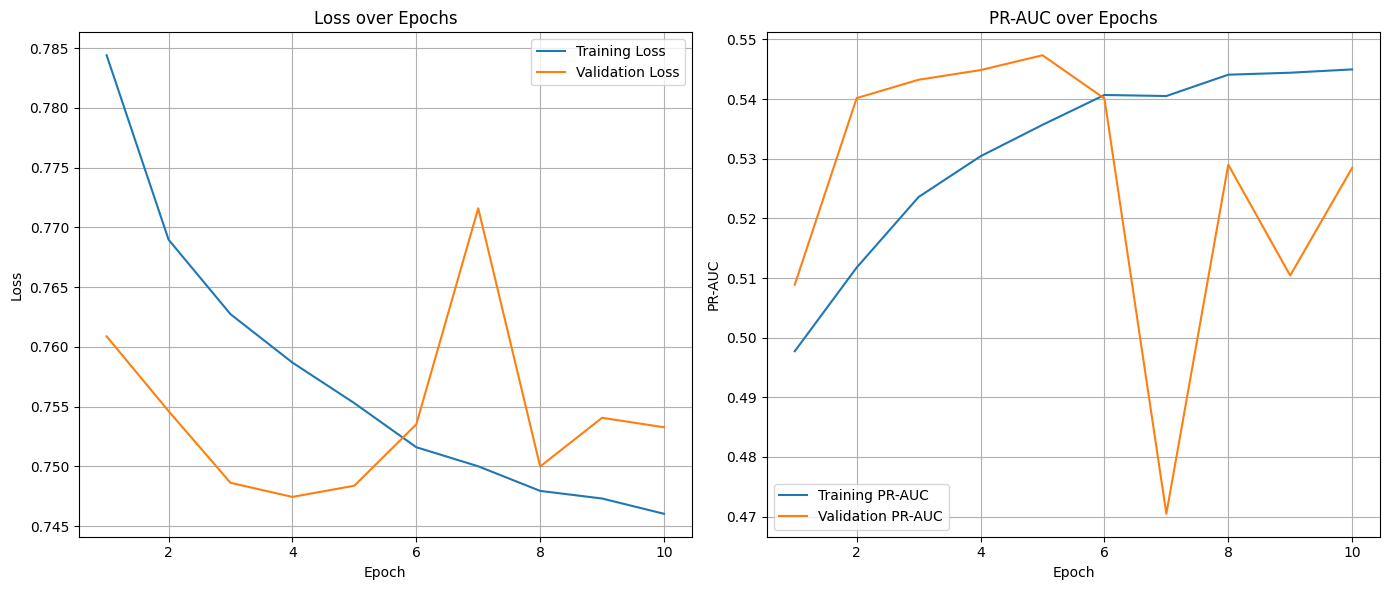


--- Evaluating ---

Матрица Ошибок
[[172883  88954]
 [  4972  47764]]

Отчет по Классификации
              precision    recall  f1-score   support

         0.0       0.97      0.66      0.79    261837
         1.0       0.35      0.91      0.50     52736

    accuracy                           0.70    314573
   macro avg       0.66      0.78      0.65    314573
weighted avg       0.87      0.70      0.74    314573

Test Set PR-AUC: 0.5234


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


X_train_split_df, X_val_split_df, y_train_split_s, y_val_split_s = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42, stratify=y_train
)

X_train_nn = torch.tensor(X_train_split_df.astype(float).values, dtype=torch.float32)
y_train_nn = torch.tensor(y_train_split_s.values, dtype=torch.float32).unsqueeze(1)

X_val_nn = torch.tensor(X_val_split_df.astype(float).values, dtype=torch.float32)
y_val_nn = torch.tensor(y_val_split_s.values, dtype=torch.float32).unsqueeze(1)

X_test_nn = torch.tensor(X_test.astype(float).values, dtype=torch.float32)
y_test_nn = torch.tensor(y_test.values, dtype=torch.float32).unsqueeze(1)

batch_size = 64
train_dataset = TensorDataset(X_train_nn, y_train_nn)
val_dataset = TensorDataset(X_val_nn, y_val_nn)
test_dataset = TensorDataset(X_test_nn, y_test_nn)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

class FraudDetectorNN(nn.Module):
    def __init__(self, input_size):
        super(FraudDetectorNN, self).__init__()
        self.layer1 = nn.Linear(input_size, 512)
        self.bn1 = nn.BatchNorm1d(512)
        self.relu1 = nn.ReLU()
        self.dropout1 = nn.Dropout(0.5)

        self.layer2 = nn.Linear(512, 256)
        self.bn2 = nn.BatchNorm1d(256)
        self.relu2 = nn.ReLU()
        self.dropout2 = nn.Dropout(0.4)

        self.layer3 = nn.Linear(256, 128)
        self.bn3 = nn.BatchNorm1d(128)
        self.relu3 = nn.ReLU()
        self.dropout3 = nn.Dropout(0.3)

        self.layer4 = nn.Linear(128, 64)
        self.bn4 = nn.BatchNorm1d(64)
        self.relu4 = nn.ReLU()
        self.dropout4 = nn.Dropout(0.2)

        self.output_layer = nn.Linear(64, 1)

    def forward(self, x):
        x = self.dropout1(self.relu1(self.bn1(self.layer1(x))))
        x = self.dropout2(self.relu2(self.bn2(self.layer2(x))))
        x = self.dropout3(self.relu3(self.bn3(self.layer3(x))))
        x = self.dropout4(self.relu4(self.bn4(self.layer4(x))))
        x = self.output_layer(x)
        return x


input_size = X_train_nn.shape[1]
model = FraudDetectorNN(input_size).to(device)


neg_count = (y_train_split_s == 0).sum()
pos_count = (y_train_split_s == 1).sum()
scaling_factor = 1.0
pos_weight = torch.tensor([neg_count / pos_count * scaling_factor], dtype=torch.float32).to(device)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = optim.Adam(model.parameters(), lr=0.0005)

epochs = 10
train_losses = []
val_losses = []
train_pr_auc_scores = []
val_pr_auc_scores = []

print("\n--- Training ---")
for epoch in tqdm(range(epochs)):
    model.train()
    running_loss = 0.0
    all_train_probs = []
    all_train_labels = []

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()


        probabilities = torch.sigmoid(outputs)
        all_train_probs.extend(probabilities.detach().cpu().numpy())
        all_train_labels.extend(labels.detach().cpu().numpy())

    train_epoch_loss = running_loss / len(train_loader)
    train_epoch_pr_auc = average_precision_score(
        np.array(all_train_labels).flatten(),
        np.array(all_train_probs).flatten()
    )
    train_losses.append(train_epoch_loss)
    train_pr_auc_scores.append(train_epoch_pr_auc)

    model.eval()
    val_running_loss = 0.0
    all_val_probs = []
    all_val_labels = []

    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_running_loss += loss.item()

            probabilities = torch.sigmoid(outputs)
            all_val_probs.extend(probabilities.detach().cpu().numpy())
            all_val_labels.extend(labels.detach().cpu().numpy())

    val_epoch_loss = val_running_loss / len(val_loader)
    val_epoch_pr_auc = average_precision_score(
        np.array(all_val_labels).flatten(),
        np.array(all_val_probs).flatten()
    )
    val_losses.append(val_epoch_loss)
    val_pr_auc_scores.append(val_epoch_pr_auc)

    print(f"Epoch {epoch+1}, Train Loss: {train_epoch_loss:.4f}, Train PR-AUC: {train_epoch_pr_auc:.4f}, Val Loss: {val_epoch_loss:.4f}, Val PR-AUC: {val_epoch_pr_auc:.4f}")


plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.plot(range(1, epochs + 1), train_losses, label='Training Loss')
plt.plot(range(1, epochs + 1), val_losses, label='Validation Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(range(1, epochs + 1), train_pr_auc_scores, label='Training PR-AUC')
plt.plot(range(1, epochs + 1), val_pr_auc_scores, label='Validation PR-AUC')
plt.title('PR-AUC over Epochs')
plt.xlabel('Epoch')
plt.ylabel('PR-AUC')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

##### Валидация

In [ ]:
print("\n--- Evaluating ---")
model.eval()
y_pred_nn_list = []
y_test_nn_list = []
all_test_probs = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        probabilities = torch.sigmoid(outputs)
        predictions = (probabilities > 0.5).float()

        y_pred_nn_list.extend(predictions.detach().cpu().numpy())
        y_test_nn_list.extend(labels.detach().cpu().numpy())
        all_test_probs.extend(probabilities.detach().cpu().numpy())

y_pred_nn = np.array(y_pred_nn_list)
y_test_nn_actual = np.array(y_test_nn_list)
y_pred_proba_test = np.array(all_test_probs)

conf_matrix = confusion_matrix(y_test_nn_actual, y_pred_nn)
print("\nМатрица Ошибок")
print(conf_matrix)

print("\nОтчет по Классификации")
print(classification_report(y_test_nn_actual, y_pred_nn))

test_pr_auc = average_precision_score(y_test_nn_actual, y_pred_proba_test)
print(f"Test Set PR-AUC: {test_pr_auc:.4f}")

Во время обучения мы отслеживали поведение функции потерь и метрики PR-AUC, видим, что на трейне все шло монотонно - loss падал, метрика росла. На валидации же картина нестабильная, несмотря на принятые меры для снижения переобучения сети, и loss, и PR-AUC принимали наилучшие значения на 4-5 эпохах обучения, после чего начинались значительные колебания.
При этом отчет по классификации показывает, что метрики precision, recall и f1 сравнимы с таковыми на предыдущих линейных моделях и деревьях, но всё же уступают им.

##### Валидация

Best F1-score found: 0.5134 at threshold: 0.6821


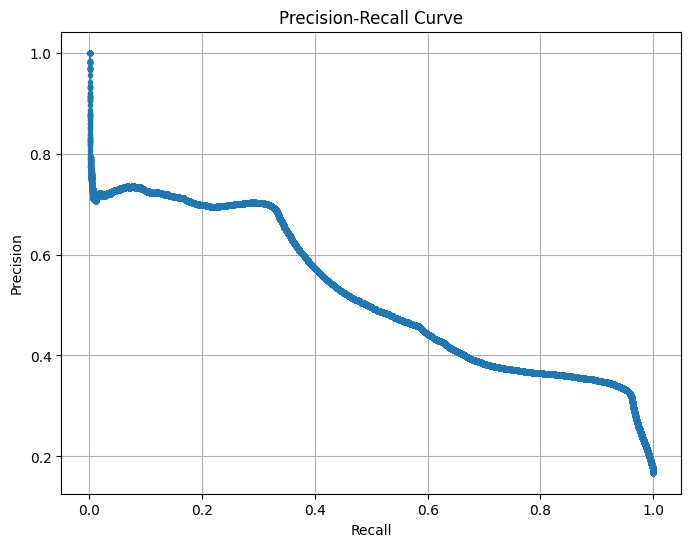


Матрица Ошибок
[[225146  36691]
 [ 21852  30884]]

Отчет по Классификации
              precision    recall  f1-score   support

         0.0       0.91      0.86      0.88    261837
         1.0       0.46      0.59      0.51     52736

    accuracy                           0.81    314573
   macro avg       0.68      0.72      0.70    314573
weighted avg       0.84      0.81      0.82    314573



In [ ]:
model.eval()
all_test_probs = []
with torch.no_grad():
    for inputs, _ in test_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        probabilities = torch.sigmoid(outputs)
        all_test_probs.extend(probabilities.cpu().numpy())

y_pred_proba = np.array(all_test_probs).flatten()
y_test_nn_actual = y_test_nn_actual.flatten()

precision, recall, thresholds = precision_recall_curve(y_test_nn_actual, y_pred_proba)

f1_scores = 2 * (precision * recall) / (precision + recall)
f1_scores = np.nan_to_num(f1_scores)
best_f1_index = np.argmax(f1_scores)
best_threshold = thresholds[best_f1_index]
best_f1_score = f1_scores[best_f1_index]

print(f"Best F1-score found: {best_f1_score:.4f} at threshold: {best_threshold:.4f}")

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, marker='.')
plt.title('Precision-Recall Curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.grid(True)
plt.show()

y_pred_optimized = (y_pred_proba >= best_threshold).astype(int)

conf_matrix_optimized = confusion_matrix(y_test_nn_actual, y_pred_optimized)
print("\nМатрица Ошибок")
print(conf_matrix_optimized)

print("\nОтчет по Классификации")
print(classification_report(y_test_nn_actual, y_pred_optimized))

Попытка подобрать лучший порог для классификации на практике не дала прироста качества по всем показателям. В 0-м классе получили повышение метрик, повысилась точность на 1-м классе, но при этом доля обнаруженного фрода составила всего 59%.

##### **Расчет ROC AUC и построение ROC-кривой**

ROC AUC Score: 0.8493


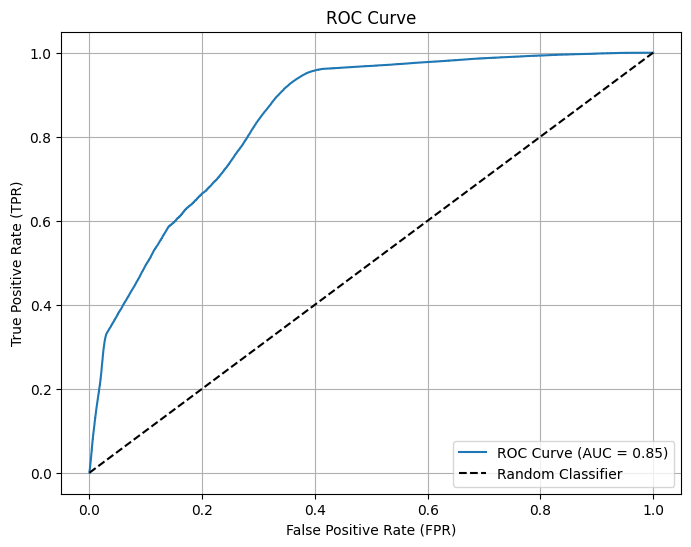

In [ ]:
from sklearn.metrics import roc_auc_score, roc_curve


roc_auc = roc_auc_score(y_test_nn_actual, y_pred_proba)
print(f"ROC AUC Score: {roc_auc:.4f}")


fpr, tpr, thresholds = roc_curve(y_test_nn_actual, y_pred_proba)


plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

##### MLflow логирование

In [ ]:
params = {
    "architecture": "FraudDetectorNN",
    "input_size": input_size,
    "hidden_layers": "512-256-128-64",
    "batch_norm": True,
    "dropout": "0.5-0.4-0.3-0.2",
    "batch_size": batch_size,
    "epochs": epochs,
    "optimizer": "Adam",
    "learning_rate": 0.0005,
    "loss_function": "BCEWithLogitsLoss",
    "pos_weight": float(pos_weight.detach().cpu().item()),
    "threshold": 0.5,
    "best_threshold": float(best_threshold),
}

with mlflow.start_run(experiment_id=exp_id, run_name="Model #6. Fully Connected Neural Network"):
    print("Artifact URI for this run:", mlflow.get_artifact_uri())

    y_true = np.asarray(y_test_nn_actual).reshape(-1).astype(int)
    y_pred = np.asarray(y_pred_nn).reshape(-1).astype(int)
    proba = np.asarray(y_pred_proba).reshape(-1)
    y_pred_best_threshold = np.asarray(y_pred_optimized).reshape(-1).astype(int)

    metrics = {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, pos_label=1, zero_division=0),
        "recall": recall_score(y_true, y_pred, pos_label=1, zero_division=0),
        "f1_score": f1_score(y_true, y_pred, pos_label=1, zero_division=0),
        "f2_score": fbeta_score(y_true, y_pred, pos_label=1, beta=2, zero_division=0),
        "roc_auc": roc_auc_score(y_true, proba),
        "pr_auc": average_precision_score(y_true, proba),
        "best_f1_score": float(best_f1_score),
        "optimized_accuracy": accuracy_score(y_true, y_pred_best_threshold),
        "optimized_precision": precision_score(y_true, y_pred_best_threshold, pos_label=1, zero_division=0),
        "optimized_recall": recall_score(y_true, y_pred_best_threshold, pos_label=1, zero_division=0),
        "optimized_f1_score": f1_score(y_true, y_pred_best_threshold, pos_label=1, zero_division=0),
        "optimized_f2_score": fbeta_score(y_true, y_pred_best_threshold, pos_label=1, beta=2, zero_division=0),
    }

    conf_matrix = confusion_matrix(y_true, y_pred)

    fig, ax = plt.subplots(figsize=(6, 4))
    sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", ax=ax)
    ax.set_xlabel("Предсказано")
    ax.set_ylabel("Истинно")
    ax.set_title("Матрица ошибок")
    plt.tight_layout()

    mlflow.log_figure(fig, "confusion_matrix.png")
    plt.close(fig)

    conf_matrix_optimized = confusion_matrix(y_true, y_pred_best_threshold)

    fig, ax = plt.subplots(figsize=(6, 4))
    sns.heatmap(conf_matrix_optimized, annot=True, fmt="d", cmap="Blues", ax=ax)
    ax.set_xlabel("Предсказано")
    ax.set_ylabel("Истинно")
    ax.set_title("Матрица ошибок")
    plt.tight_layout()

    mlflow.log_figure(fig, "confusion_matrix_optimized_threshold.png")
    plt.close(fig)

    report = classification_report(y_true, y_pred, zero_division=0)
    mlflow.log_text(report, "classification_report.txt")

    report_optimized = classification_report(y_true, y_pred_best_threshold, zero_division=0)
    mlflow.log_text(report_optimized, "classification_report_optimized_threshold.txt")

    fig, ax = plt.subplots(figsize=(8, 6))
    ax.plot(recall, precision, marker=".")
    ax.set_title("Precision-Recall Curve")
    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")
    ax.grid(True)
    plt.tight_layout()

    mlflow.log_figure(fig, "precision_recall_curve.png")
    plt.close(fig)

    fig, ax = plt.subplots(figsize=(8, 6))
    ax.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.2f})")
    ax.plot([0, 1], [0, 1], "k--", label="Random Classifier")
    ax.set_xlabel("False Positive Rate (FPR)")
    ax.set_ylabel("True Positive Rate (TPR)")
    ax.set_title("ROC Curve")
    ax.legend(loc="lower right")
    ax.grid(True)
    plt.tight_layout()

    mlflow.log_figure(fig, "roc_curve.png")
    plt.close(fig)

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    axes[0].plot(range(1, epochs + 1), train_losses, label="Training Loss")
    axes[0].plot(range(1, epochs + 1), val_losses, label="Validation Loss")
    axes[0].set_title("Loss over Epochs")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].legend()
    axes[0].grid(True)

    axes[1].plot(range(1, epochs + 1), train_pr_auc_scores, label="Training PR-AUC")
    axes[1].plot(range(1, epochs + 1), val_pr_auc_scores, label="Validation PR-AUC")
    axes[1].set_title("PR-AUC over Epochs")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("PR-AUC")
    axes[1].legend()
    axes[1].grid(True)
    plt.tight_layout()

    mlflow.log_figure(fig, "training_curves.png")
    plt.close(fig)

    mlflow.log_params(params)
    mlflow.log_metrics(metrics)

    for epoch_idx, (train_loss, val_loss, train_pr_auc, val_pr_auc) in enumerate(
        zip(train_losses, val_losses, train_pr_auc_scores, val_pr_auc_scores),
        start=1,
    ):
        mlflow.log_metric("train_loss", train_loss, step=epoch_idx)
        mlflow.log_metric("val_loss", val_loss, step=epoch_idx)
        mlflow.log_metric("train_pr_auc", train_pr_auc, step=epoch_idx)
        mlflow.log_metric("val_pr_auc", val_pr_auc, step=epoch_idx)

    signature = infer_signature(X_test.astype(np.float32), proba.reshape(-1, 1))

    model_info = mlflow.pytorch.log_model(
        pytorch_model=model,
        artifact_path="model",
        signature=signature,
        registered_model_name=registered_model_name,
    )

    mlflow.log_input(
        mlflow.data.from_pandas(df, source="../data/raw/Fraud.csv"),
        context="training",
    )

    client = MlflowClient()
    new_version = model_info.registered_model_version

    client.set_model_version_tag(
        registered_model_name,
        new_version,
        "env",
        "training",
    )

    client.set_registered_model_alias(
        registered_model_name,
        "training",
        new_version,
    )

    run_id = mlflow.active_run().info.run_id

    print("Run ID:", run_id)
    print("Registered model version:", new_version)
    print("Alias 'training' points to version:", new_version)
    print("Metrics:", metrics)

ROC AUC кривая показывает неплохую стабильность предсказаний

#### *Модель №2. Полносвязная НН с регуляризацией*

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class RegularizedFraudDetectorNN(nn.Module):
    def __init__(self, input_size):
        super(RegularizedFraudDetectorNN, self).__init__()
        self.layer1 = nn.Linear(input_size, 512)
        self.bn1 = nn.BatchNorm1d(512)
        self.relu1 = nn.ReLU()
        self.dropout1 = nn.Dropout(0.5)

        self.layer2 = nn.Linear(512, 256)
        self.bn2 = nn.BatchNorm1d(256)
        self.relu2 = nn.ReLU()
        self.dropout2 = nn.Dropout(0.4)

        self.layer3 = nn.Linear(256, 128)
        self.bn3 = nn.BatchNorm1d(128)
        self.relu3 = nn.ReLU()
        self.dropout3 = nn.Dropout(0.3)

        self.layer4 = nn.Linear(128, 64)
        self.bn4 = nn.BatchNorm1d(64)
        self.relu4 = nn.ReLU()
        self.dropout4 = nn.Dropout(0.2)

        self.output_layer = nn.Linear(64, 1)

    def forward(self, x):
        x = self.dropout1(self.relu1(self.bn1(self.layer1(x))))
        x = self.dropout2(self.relu2(self.bn2(self.layer2(x))))
        x = self.dropout3(self.relu3(self.bn3(self.layer3(x))))
        x = self.dropout4(self.relu4(self.bn4(self.layer4(x))))
        x = self.output_layer(x)
        return x


model_regularized = RegularizedFraudDetectorNN(input_size=22).to(device)

neg_count_val = 587200 - 98579
pos_count_val = 98579


scaling_factor = 1.0
pos_weight = torch.tensor([neg_count_val / pos_count_val * scaling_factor], dtype=torch.float32).to(device)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

optimizer_regularized = optim.Adam(model_regularized.parameters(), lr=0.0005, weight_decay=1e-4)

print("RegularizedFraudDetectorNN model and optimizer with L2 regularization (weight_decay) configured.")
print(f"Optimizer learning rate: {optimizer_regularized.defaults['lr']}")
print(f"Optimizer weight decay (L2 regularization): {optimizer_regularized.defaults['weight_decay']}")


RegularizedFraudDetectorNN model and optimizer with L2 regularization (weight_decay) configured.
Optimizer learning rate: 0.0005
Optimizer weight decay (L2 regularization): 0.0001


##### *Обучение*


--- Training  ---


 10%|█         | 1/10 [00:50<07:37, 50.80s/it]

Epoch 1, Train Loss: 0.7829, Train F1: 0.4866, Val Loss: 0.7583, Val F1: 0.4931


 20%|██        | 2/10 [01:34<06:10, 46.37s/it]

Epoch 2, Train Loss: 0.7712, Train F1: 0.4912, Val Loss: 0.7555, Val F1: 0.4972


...

Epoch 8, Train Loss: 0.7542, Train F1: 0.5052, Val Loss: 0.7596, Val F1: 0.5027


 90%|█████████ | 9/10 [06:33<00:43, 43.05s/it]

Epoch 9, Train Loss: 0.7546, Train F1: 0.5050, Val Loss: 0.7498, Val F1: 0.4986


100%|██████████| 10/10 [07:16<00:00, 43.69s/it]

Epoch 10, Train Loss: 0.7540, Train F1: 0.5044, Val Loss: 0.7495, Val F1: 0.5022


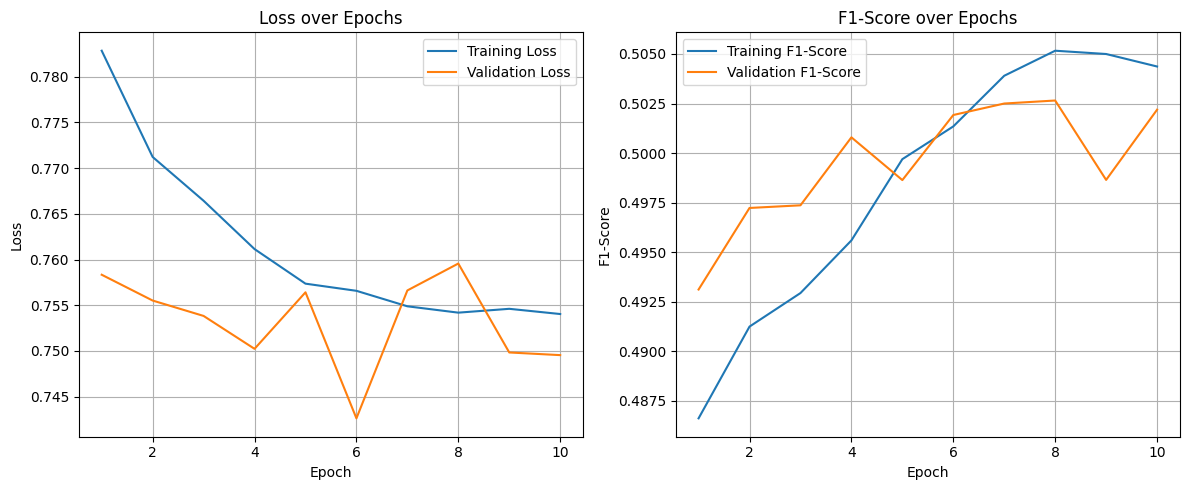

In [ ]:
epochs = 10
train_losses_reg = []
val_losses_reg = []
train_f1_scores_reg = []
val_f1_scores_reg = []

print("\n--- Training  ---")
for epoch in tqdm(range(epochs)):
    model_regularized.train()
    running_loss = 0.0
    all_train_preds = []
    all_train_labels = []

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer_regularized.zero_grad()
        outputs = model_regularized(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer_regularized.step()
        running_loss += loss.item()

        probabilities = torch.sigmoid(outputs)
        predictions = (probabilities > 0.5).float()
        all_train_preds.extend(predictions.cpu().numpy())
        all_train_labels.extend(labels.cpu().numpy())

    train_epoch_loss = running_loss / len(train_loader)
    train_epoch_f1 = f1_score(np.array(all_train_labels).flatten(), np.array(all_train_preds).flatten())
    train_losses_reg.append(train_epoch_loss)
    train_f1_scores_reg.append(train_epoch_f1)


    model_regularized.eval()
    val_running_loss = 0.0
    all_val_preds = []
    all_val_labels = []

    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model_regularized(inputs)
            loss = criterion(outputs, labels)
            val_running_loss += loss.item()

            probabilities = torch.sigmoid(outputs)
            predictions = (probabilities > 0.5).float()
            all_val_preds.extend(predictions.cpu().numpy())
            all_val_labels.extend(labels.cpu().numpy())

    val_epoch_loss = val_running_loss / len(val_loader)
    val_epoch_f1 = f1_score(np.array(all_val_labels).flatten(), np.array(all_val_preds).flatten())
    val_losses_reg.append(val_epoch_loss)
    val_f1_scores_reg.append(val_epoch_f1)

    print(f"Epoch {epoch+1}, Train Loss: {train_epoch_loss:.4f}, Train F1: {train_epoch_f1:.4f}, Val Loss: {val_epoch_loss:.4f}, Val F1: {val_epoch_f1:.4f}")

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(range(1, epochs + 1), train_losses_reg, label='Training Loss')
plt.plot(range(1, epochs + 1), val_losses_reg, label='Validation Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(range(1, epochs + 1), train_f1_scores_reg, label='Training F1-Score')
plt.plot(range(1, epochs + 1), val_f1_scores_reg, label='Validation F1-Score')
plt.title('F1-Score over Epochs')
plt.xlabel('Epoch')
plt.ylabel('F1-Score')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

После регуляризации сеть стала вести себя стабильнее во время обучения, хотя перепады на графиках всё еще остались

##### Валидация

*Оценим качество сети на тестовых данных*

In [ ]:
print("\n--- Evaluating ---")
model_regularized.eval()
y_pred_nn_list_reg = []
y_test_nn_list_reg = []
all_test_probs_reg = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model_regularized(inputs)
        probabilities = torch.sigmoid(outputs)
        predictions = (probabilities > 0.5).float()
        y_pred_nn_list_reg.extend(predictions.detach().cpu().numpy())
        y_test_nn_list_reg.extend(labels.detach().cpu().numpy())
        all_test_probs_reg.extend(probabilities.detach().cpu().numpy())

y_pred_nn_reg = np.array(y_pred_nn_list_reg)
y_test_nn_actual_reg = np.array(y_test_nn_list_reg)
y_pred_proba_reg = np.array(all_test_probs_reg)

conf_matrix_reg = confusion_matrix(y_test_nn_actual_reg, y_pred_nn_reg)
print("\nМатрица Ошибок")
print(conf_matrix_reg)

print("\nОтчет по Классификации")
print(classification_report(y_test_nn_actual_reg, y_pred_nn_reg))

test_pr_auc_reg = average_precision_score(y_test_nn_actual_reg, y_pred_proba_reg)
print(f"Test PR-AUC: {test_pr_auc_reg:.4f}")


--- Evaluating ---

Матрица Ошибок
[[170704  91133]
 [  4530  48206]]

Отчет по Классификации
              precision    recall  f1-score   support

         0.0       0.97      0.65      0.78    261837
         1.0       0.35      0.91      0.50     52736

    accuracy                           0.70    314573
   macro avg       0.66      0.78      0.64    314573
weighted avg       0.87      0.70      0.73    314573



##### MLflow логирование

In [ ]:
params = {
    "architecture": "RegularizedFraudDetectorNN",
    "input_size": X_train_nn.shape[1],
    "hidden_layers": "512-256-128-64",
    "batch_norm": True,
    "dropout": "0.5-0.4-0.3-0.2",
    "batch_size": batch_size,
    "epochs": epochs,
    "optimizer": "Adam",
    "learning_rate": optimizer_regularized.defaults["lr"],
    "weight_decay": optimizer_regularized.defaults["weight_decay"],
    "loss_function": "BCEWithLogitsLoss",
    "pos_weight": float(pos_weight.detach().cpu().item()),
    "threshold": 0.5,
}

with mlflow.start_run(experiment_id=exp_id, run_name="Model #7. Regularized Fully Connected Neural Network"):
    print("Artifact URI for this run:", mlflow.get_artifact_uri())

    y_true = np.asarray(y_test_nn_actual_reg).reshape(-1).astype(int)
    y_pred = np.asarray(y_pred_nn_reg).reshape(-1).astype(int)
    proba = np.asarray(y_pred_proba_reg).reshape(-1)

    metrics = {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, pos_label=1, zero_division=0),
        "recall": recall_score(y_true, y_pred, pos_label=1, zero_division=0),
        "f1_score": f1_score(y_true, y_pred, pos_label=1, zero_division=0),
        "f2_score": fbeta_score(y_true, y_pred, pos_label=1, beta=2, zero_division=0),
        "roc_auc": roc_auc_score(y_true, proba),
        "pr_auc": average_precision_score(y_true, proba),
    }

    conf_matrix = confusion_matrix(y_true, y_pred)

    fig, ax = plt.subplots(figsize=(6, 4))
    sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", ax=ax)
    ax.set_xlabel("Предсказано")
    ax.set_ylabel("Истинно")
    ax.set_title("Матрица ошибок")
    plt.tight_layout()

    mlflow.log_figure(fig, "confusion_matrix.png")
    plt.close(fig)

    report = classification_report(y_true, y_pred, zero_division=0)

    mlflow.log_text(report, "classification_report.txt")

    print("\nМатрица Ошибок")
    print(conf_matrix)

    print("\nОтчет по Классификации")
    print(report)

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    axes[0].plot(range(1, epochs + 1), train_losses_reg, label="Training Loss")
    axes[0].plot(range(1, epochs + 1), val_losses_reg, label="Validation Loss")
    axes[0].set_title("Loss over Epochs")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].legend()
    axes[0].grid(True)

    axes[1].plot(range(1, epochs + 1), train_f1_scores_reg, label="Training F1-Score")
    axes[1].plot(range(1, epochs + 1), val_f1_scores_reg, label="Validation F1-Score")
    axes[1].set_title("F1-Score over Epochs")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("F1-Score")
    axes[1].legend()
    axes[1].grid(True)
    plt.tight_layout()

    mlflow.log_figure(fig, "training_curves.png")
    plt.close(fig)

    mlflow.log_params(params)
    mlflow.log_metrics(metrics)

    for epoch_idx, (train_loss, val_loss, train_f1, val_f1) in enumerate(
        zip(train_losses_reg, val_losses_reg, train_f1_scores_reg, val_f1_scores_reg),
        start=1,
    ):
        mlflow.log_metric("train_loss", train_loss, step=epoch_idx)
        mlflow.log_metric("val_loss", val_loss, step=epoch_idx)
        mlflow.log_metric("train_f1_score", train_f1, step=epoch_idx)
        mlflow.log_metric("val_f1_score", val_f1, step=epoch_idx)

    signature = infer_signature(X_test.astype(np.float32), proba.reshape(-1, 1))

    model_info = mlflow.pytorch.log_model(
        pytorch_model=model_regularized,
        artifact_path="model",
        signature=signature,
        registered_model_name=registered_model_name,
    )

    mlflow.log_input(
        mlflow.data.from_pandas(df, source="../data/raw/Fraud.csv"),
        context="training",
    )

    client = MlflowClient()
    new_version = model_info.registered_model_version

    client.set_model_version_tag(
        registered_model_name,
        new_version,
        "env",
        "training",
    )

    client.set_registered_model_alias(
        registered_model_name,
        "training",
        new_version,
    )

    run_id = mlflow.active_run().info.run_id

    print("Run ID:", run_id)
    print("Registered model version:", new_version)
    print("Alias 'training' points to version:", new_version)
    print("Metrics:", metrics)

Регуляризация помогла лучше определять фродовые операции - полнота выросла до 91%, именно это нас, в первую очередь, и интересует, но модели выше показывали и более высокие результаты

##### Оптимизация

*С помощью Optuna попробуем подобрать лучшие гиперпараметры сети*

In [ ]:
class TunableFraudDetectorNN(nn.Module):
    def __init__(self, input_size, n_layers, n_units, dropout_rate):
        super(TunableFraudDetectorNN, self).__init__()
        layers = []
        in_features = input_size

        for i in range(n_layers):
            out_features = n_units[i]
            layers.append(nn.Linear(in_features, out_features))
            layers.append(nn.BatchNorm1d(out_features))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout_rate[i]))
            in_features = out_features

        self.hidden_layers = nn.Sequential(*layers)
        self.output_layer = nn.Linear(in_features, 1)

    def forward(self, x):
        x = self.hidden_layers(x)
        x = self.output_layer(x)
        return x

def objective_nn(trial):
    n_layers = trial.suggest_int('n_layers', 2, 4)

    n_units = []
    dropout_rate = []
    for i in range(n_layers):
        n_units.append(trial.suggest_int(f'n_units_l{i}', 64, 512, step=64))
        dropout_rate.append(trial.suggest_float(f'dropout_l{i}', 0.1, 0.5, step=0.1))

    learning_rate = trial.suggest_float('learning_rate', 1e-5, 1e-3, log=True)
    weight_decay = trial.suggest_float('weight_decay', 1e-6, 1e-3, log=True)

    model = TunableFraudDetectorNN(input_size=X_train_nn.shape[1],
                                   n_layers=n_layers,
                                   n_units=n_units,
                                   dropout_rate=dropout_rate).to(device)

    pos_weight_val = torch.tensor([neg_count_val / pos_count_val * 1.0], dtype=torch.float32).to(device)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight_val)
    optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)

    tuning_epochs = 5
    for epoch in range(tuning_epochs):
        model.train()
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

    model.eval()
    all_val_probs = []
    all_val_labels = []
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            probabilities = torch.sigmoid(outputs)
            all_val_probs.extend(probabilities.detach().cpu().numpy())
            all_val_labels.extend(labels.detach().cpu().numpy())

    val_pr_auc = average_precision_score(np.array(all_val_labels).flatten(), np.array(all_val_probs).flatten())
    return val_pr_auc

y
print("\n--- Starting Optuna ---")
study = optuna.create_study(direction='maximize')
study.optimize(objective_nn, n_trials=30)

print("\nBest trial:")
print(f"  Value (PR-AUC): {study.best_value:.4f}")
print("  Params: ")
for key, value in study.best_params.items():
    print(f"    {key}: {value}")


best_params = study.best_params

n_layers_final = best_params['n_layers']
n_units_final = [best_params[f'n_units_l{i}'] for i in range(n_layers_final)]
dropout_rate_final = [best_params[f'dropout_l{i}'] for i in range(n_layers_final)]

final_model = TunableFraudDetectorNN(input_size=X_train_nn.shape[1],
                                     n_layers=n_layers_final,
                                     n_units=n_units_final,
                                     dropout_rate=dropout_rate_final).to(device)

pos_weight_final = torch.tensor([neg_count_val / pos_count_val * 1.0], dtype=torch.float32).to(device)
criterion_final = nn.BCEWithLogitsLoss(pos_weight=pos_weight_final)
optimizer_final = optim.Adam(final_model.parameters(),
                             lr=best_params['learning_rate'],
                             weight_decay=best_params['weight_decay'])


final_epochs = 20
print(f"\n--- Training ---")
for epoch in tqdm(range(final_epochs)):
    final_model.train()
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer_final.zero_grad()
        outputs = final_model(inputs)
        loss = criterion_final(outputs, labels)
        loss.backward()
        optimizer_final.step()


print("\n--- Evaluating  ---")
final_model.eval()
y_pred_nn_final_list = []
y_test_nn_final_list = []
all_test_probs_final = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = final_model(inputs)
        probabilities = torch.sigmoid(outputs)
        predictions = (probabilities > 0.5).float()

        y_pred_nn_final_list.extend(predictions.detach().cpu().numpy())
        y_test_nn_final_list.extend(labels.detach().cpu().numpy())
        all_test_probs_final.extend(probabilities.detach().cpu().numpy())

y_pred_nn_final = np.array(y_pred_nn_final_list)
y_test_nn_actual_final = np.array(y_test_nn_final_list)

conf_matrix_final = confusion_matrix(y_test_nn_actual_final, y_pred_nn_final)
print("\nМатрица Ошибок")
print(conf_matrix_final)

print("\nОтчет по Классификации")
print(classification_report(y_test_nn_actual_final, y_pred_nn_final))

test_pr_auc_final = average_precision_score(y_test_nn_actual_final, np.array(all_test_probs_final))
print(f"Test Set PR-AUC: {test_pr_auc_final:.4f}")

[I 2026-04-30 19:04:10,325] A new study created in memory with name: no-name-614d9288-6b41-4762-89ed-da198eca4ad6



--- Starting Optuna ---


[I 2026-04-30 19:06:24,247] Trial 0 finished with value: 0.49519860168266167 and parameters: {'n_layers': 2, 'n_units_l0': 448, 'dropout_l0': 0.30000000000000004, 'n_units_l1': 512, 'dropout_l1': 0.1, 'learning_rate': 0.0009715994455112126, 'weight_decay': 8.809026164492102e-06}. Best is trial 0 with value: 0.49519860168266167.
[I 2026-04-30 19:09:08,910] Trial 1 finished with value: 0.5249185820404357 and parameters: {'n_layers': 3, 'n_units_l0': 320, 'dropout_l0': 0.30000000000000004, 'n_units_l1': 128, 'dropout_l1': 0.4, 'n_units_l2': 512, 'dropout_l2': 0.30000000000000004, 'learning_rate': 0.0006321822966614089, 'weight_decay': 2.7546495888517234e-05}. Best is trial 1 with value: 0.5249185820404357.
[I 2026-04-30 19:12:06,020] Trial 2 finished with value: 0.4965053008505233 and parameters: {'n_layers': 4, 'n_units_l0': 256, 'dropout_l0': 0.4, 'n_units_l1': 384, 'dropout_l1': 0.4, 'n_units_l2': 64, 'dropout_l2': 0.5, 'n_units_l3': 384, 'dropout_l3': 0.5, 'learning_rate': 1.143748537


Best trial:
  Value (PR-AUC): 0.5553
  Params: 
    n_layers: 3
    n_units_l0: 192
    dropout_l0: 0.2
    n_units_l1: 320
    dropout_l1: 0.1
    n_units_l2: 256
    dropout_l2: 0.2
    learning_rate: 0.0002551831724766059
    weight_decay: 2.281385251974979e-05

--- Training ---


100%|██████████| 20/20 [09:59<00:00, 29.98s/it]



--- Evaluating  ---

Матрица Ошибок
[[179926  81911]
 [  7218  45518]]

Отчет по Классификации
              precision    recall  f1-score   support

         0.0       0.96      0.69      0.80    261837
         1.0       0.36      0.86      0.51     52736

    accuracy                           0.72    314573
   macro avg       0.66      0.78      0.65    314573
weighted avg       0.86      0.72      0.75    314573

Test Set PR-AUC: 0.4726


##### MLFlow логирование

In [ ]:
params = {
    "architecture": "TunableFraudDetectorNN",
    "input_size": X_train_nn.shape[1],
    "n_layers": n_layers_final,
    "n_units": str(n_units_final),
    "dropout_rate": str(dropout_rate_final),
    "batch_size": batch_size,
    "epochs": final_epochs,
    "optimizer": "Adam",
    "learning_rate": best_params["learning_rate"],
    "weight_decay": best_params["weight_decay"],
    "loss_function": "BCEWithLogitsLoss",
    "pos_weight": float(pos_weight_final.detach().cpu().item()),
    "threshold": 0.5,
    "optuna_n_trials": len(study.trials),
    "optuna_best_pr_auc": float(study.best_value),
}

with mlflow.start_run(experiment_id=exp_id, run_name="Model #8. Optuna Tuned Fully Connected Neural Network"):
    print("Artifact URI for this run:", mlflow.get_artifact_uri())

    y_true = np.asarray(y_test_nn_actual_final).reshape(-1).astype(int)
    y_pred = np.asarray(y_pred_nn_final).reshape(-1).astype(int)
    proba = np.asarray(all_test_probs_final).reshape(-1)

    metrics = {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, pos_label=1, zero_division=0),
        "recall": recall_score(y_true, y_pred, pos_label=1, zero_division=0),
        "f1_score": f1_score(y_true, y_pred, pos_label=1, zero_division=0),
        "f2_score": fbeta_score(y_true, y_pred, pos_label=1, beta=2, zero_division=0),
        "roc_auc": roc_auc_score(y_true, proba),
        "pr_auc": average_precision_score(y_true, proba),
    }

    conf_matrix = confusion_matrix(y_true, y_pred)

    fig, ax = plt.subplots(figsize=(6, 4))
    sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", ax=ax)
    ax.set_xlabel("Предсказано")
    ax.set_ylabel("Истинно")
    ax.set_title("Матрица ошибок")
    plt.tight_layout()

    mlflow.log_figure(fig, "confusion_matrix.png")
    plt.close(fig)

    report = classification_report(y_true, y_pred, zero_division=0)

    mlflow.log_text(report, "classification_report.txt")
    mlflow.log_dict(study.best_params, "optuna_best_params.json")

    print("\nМатрица Ошибок")
    print(conf_matrix)

    print("\nОтчет по Классификации")
    print(report)

    mlflow.log_params(params)
    mlflow.log_metrics(metrics)

    signature = infer_signature(X_test.astype(np.float32), proba.reshape(-1, 1))

    model_info = mlflow.pytorch.log_model(
        pytorch_model=final_model,
        artifact_path="model",
        signature=signature,
        registered_model_name=registered_model_name,
    )

    mlflow.log_input(
        mlflow.data.from_pandas(df, source="../data/raw/Fraud.csv"),
        context="training",
    )

    client = MlflowClient()
    new_version = model_info.registered_model_version

    client.set_model_version_tag(
        registered_model_name,
        new_version,
        "env",
        "training",
    )

    client.set_registered_model_alias(
        registered_model_name,
        "training",
        new_version,
    )

    run_id = mlflow.active_run().info.run_id

    print("Run ID:", run_id)
    print("Registered model version:", new_version)
    print("Alias 'training' points to version:", new_version)
    print("Metrics:", metrics)

Optuna подобрала гиперпараметры под лучшее значение PR AUC, при этом метрика f1 также выше, чем в предыдущей сети, но общий объем найденного фрода не самый высокий

## Модель №3. Attention-based

##### Обучение

In [ ]:
class SelfAttention(nn.Module):
    def __init__(self, embed_size, heads):
        super(SelfAttention, self).__init__()
        self.embed_size = embed_size
        self.heads = heads
        self.head_dim = embed_size // heads

        assert (
            self.head_dim * heads == embed_size
        )

        self.values = nn.Linear(self.head_dim, self.head_dim, bias=False)
        self.keys = nn.Linear(self.head_dim, self.head_dim, bias=False)
        self.queries = nn.Linear(self.head_dim, self.head_dim, bias=False)
        self.fc_out = nn.Linear(heads * self.head_dim, embed_size)

    def forward(self, values, keys, query, mask=None):
        N = query.shape[0]
        value_len, key_len, query_len = values.shape[1], keys.shape[1], query.shape[1]


        values = values.reshape(N, value_len, self.heads, self.head_dim)
        keys = keys.reshape(N, key_len, self.heads, self.head_dim)
        queries = query.reshape(N, query_len, self.heads, self.head_dim)

        values = self.values(values)
        keys = self.keys(keys)
        queries = self.queries(queries)

        energy = torch.einsum("nqhd,nkhd->nhqk", [queries, keys])

        if mask is not None:
            energy = energy.masked_fill(mask == 0, float("-1e20"))

        attention = torch.softmax(energy / (self.embed_size ** (1 / 2)), dim=3)


        out = torch.einsum("nhqk,nvhd->nqhd", [attention, values]).reshape(
            N, query_len, self.heads * self.head_dim
        )

        out = self.fc_out(out)
        return out

class AttentionFraudDetectorNN(nn.Module):
    def __init__(self, input_size, n_layers, n_units, dropout_rate, num_heads=4):
        super(AttentionFraudDetectorNN, self).__init__()
        layers = []
        in_features = input_size


        self.initial_embedding = nn.Linear(in_features, n_units[0])
        self.initial_bn = nn.BatchNorm1d(n_units[0])
        self.initial_relu = nn.ReLU()
        self.initial_dropout = nn.Dropout(dropout_rate[0])


        self.attention = SelfAttention(n_units[0], num_heads)


        in_features_attn = n_units[0]
        for i in range(1, n_layers):
            out_features = n_units[i]
            layers.append(nn.Linear(in_features_attn, out_features))
            layers.append(nn.BatchNorm1d(out_features))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout_rate[i]))
            in_features_attn = out_features

        self.hidden_layers = nn.Sequential(*layers)
        self.output_layer = nn.Linear(in_features_attn, 1)

    def forward(self, x):
        x_emb = self.initial_embedding(x)
        x_emb = self.initial_bn(x_emb)
        x_emb = self.initial_relu(x_emb)
        x_emb = self.initial_dropout(x_emb)

        x_attn = self.attention(x_emb.unsqueeze(1), x_emb.unsqueeze(1), x_emb.unsqueeze(1)).squeeze(1)


        x = self.hidden_layers(x_attn)
        x = self.output_layer(x)
        return x


n_layers_attn = best_params.get('n_layers', 3)
n_units_attn = [
    best_params.get('n_units_l0', 192),
    best_params.get('n_units_l1', 320),
    best_params.get('n_units_l2', 256)
]
dropout_rate_attn = [
    best_params.get('dropout_l0', 0.2),
    best_params.get('dropout_l1', 0.1),
    best_params.get('dropout_l2', 0.2)
]

while len(n_units_attn) < n_layers_attn:
    n_units_attn.append(n_units_attn[-1])
while len(dropout_rate_attn) < n_layers_attn:
    dropout_rate_attn.append(dropout_rate_attn[-1])

model_attn = AttentionFraudDetectorNN(input_size=X_train_nn.shape[1],
                                      n_layers=n_layers_attn,
                                      n_units=n_units_attn,
                                      dropout_rate=dropout_rate_attn).to(device)

pos_weight_attn = torch.tensor([neg_count_val / pos_count_val * 1.0], dtype=torch.float32).to(device)
criterion_attn = nn.BCEWithLogitsLoss(pos_weight=pos_weight_attn)
optimizer_attn = optim.Adam(model_attn.parameters(),
                             lr=best_params.get('learning_rate', 0.000255),
                             weight_decay=best_params.get('weight_decay', 2.28e-05))

epochs_attn = 20

print(f"\n--- Training Attention Model ---")
for epoch in tqdm(range(epochs_attn)):
    model_attn.train()
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer_attn.zero_grad()
        outputs = model_attn(inputs)
        loss = criterion_attn(outputs, labels)
        loss.backward()
        optimizer_attn.step()





--- Training Attention Model ---


100%|██████████| 20/20 [15:02<00:00, 45.13s/it]



--- Evaluating Attention Model ---

Матрица Ошибок
[[175960  85877]
 [  5795  46941]]

Отчет по Классификации
              precision    recall  f1-score   support

         0.0       0.97      0.67      0.79    261837
         1.0       0.35      0.89      0.51     52736

    accuracy                           0.71    314573
   macro avg       0.66      0.78      0.65    314573
weighted avg       0.87      0.71      0.75    314573

Test PR-AUC : 0.4641


Данная модель немного уступает предыдущей по показателям

##### Валидация

In [ ]:
print(f"\n--- Evaluating Attention Model ---")
model_attn.eval()
y_pred_nn_attn_list = []
y_test_nn_attn_list = []
all_test_probs_attn = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model_attn(inputs)
        probabilities = torch.sigmoid(outputs)
        predictions = (probabilities > 0.5).float()

        y_pred_nn_attn_list.extend(predictions.detach().cpu().numpy())
        y_test_nn_attn_list.extend(labels.detach().cpu().numpy())
        all_test_probs_attn.extend(probabilities.detach().cpu().numpy())

y_pred_nn_attn = np.array(y_pred_nn_attn_list)
y_test_nn_actual_attn = np.array(y_test_nn_attn_list)

conf_matrix_attn = confusion_matrix(y_test_nn_actual_attn, y_pred_nn_attn)
print("\nМатрица Ошибок")
print(conf_matrix_attn)

print("\nОтчет по Классификации")
print(classification_report(y_test_nn_actual_attn, y_pred_nn_attn))

test_pr_auc_attn = average_precision_score(y_test_nn_actual_attn, np.array(all_test_probs_attn))
print(f"Test PR-AUC : {test_pr_auc_attn:.4f}")

##### MLflow логирование

In [ ]:
params = {
    "architecture": "AttentionFraudDetectorNN",
    "input_size": X_train_nn.shape[1],
    "n_layers": n_layers_attn,
    "n_units": str(n_units_attn),
    "dropout_rate": str(dropout_rate_attn),
    "num_heads": 4,
    "batch_size": batch_size,
    "epochs": epochs_attn,
    "optimizer": "Adam",
    "learning_rate": optimizer_attn.defaults["lr"],
    "weight_decay": optimizer_attn.defaults["weight_decay"],
    "loss_function": "BCEWithLogitsLoss",
    "pos_weight": float(pos_weight_attn.detach().cpu().item()),
    "threshold": 0.5,
}

with mlflow.start_run(experiment_id=exp_id, run_name="Model #9. Attention-based Neural Network"):
    print("Artifact URI for this run:", mlflow.get_artifact_uri())

    y_true = np.asarray(y_test_nn_actual_attn).reshape(-1).astype(int)
    y_pred = np.asarray(y_pred_nn_attn).reshape(-1).astype(int)
    proba = np.asarray(all_test_probs_attn).reshape(-1)

    metrics = {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, pos_label=1, zero_division=0),
        "recall": recall_score(y_true, y_pred, pos_label=1, zero_division=0),
        "f1_score": f1_score(y_true, y_pred, pos_label=1, zero_division=0),
        "f2_score": fbeta_score(y_true, y_pred, pos_label=1, beta=2, zero_division=0),
        "roc_auc": roc_auc_score(y_true, proba),
        "pr_auc": average_precision_score(y_true, proba),
    }

    conf_matrix = confusion_matrix(y_true, y_pred)

    fig, ax = plt.subplots(figsize=(6, 4))
    sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", ax=ax)
    ax.set_xlabel("Предсказано")
    ax.set_ylabel("Истинно")
    ax.set_title("Матрица ошибок")
    plt.tight_layout()

    mlflow.log_figure(fig, "confusion_matrix.png")
    plt.close(fig)

    report = classification_report(y_true, y_pred, zero_division=0)

    mlflow.log_text(report, "classification_report.txt")

    print("\nМатрица Ошибок")
    print(conf_matrix)

    print("\nОтчет по Классификации")
    print(report)

    mlflow.log_params(params)
    mlflow.log_metrics(metrics)

    signature = infer_signature(X_test.astype(np.float32), proba.reshape(-1, 1))

    model_info = mlflow.pytorch.log_model(
        pytorch_model=model_attn,
        artifact_path="model",
        signature=signature,
        registered_model_name=registered_model_name,
    )

    mlflow.log_input(
        mlflow.data.from_pandas(df, source="../data/raw/Fraud.csv"),
        context="training",
    )

    client = MlflowClient()
    new_version = model_info.registered_model_version

    client.set_model_version_tag(
        registered_model_name,
        new_version,
        "env",
        "training",
    )

    client.set_registered_model_alias(
        registered_model_name,
        "training",
        new_version,
    )

    run_id = mlflow.active_run().info.run_id

    print("Run ID:", run_id)
    print("Registered model version:", new_version)
    print("Alias 'training' points to version:", new_version)
    print("Metrics:", metrics)

## Модель № 4. TabNet

Данная модель позиционируется как хороший инструемент для решения задач классификации, работает с табличными данными, ипользует self-attention механизм

##### Обучение

In [ ]:
X_tabnet_raw = df_new.drop('isFraud', axis=1)
y_tabnet_raw = df_new['isFraud']

X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(
    X_tabnet_raw, y_tabnet_raw,
    test_size=0.3,
    random_state=42,
    stratify=y_tabnet_raw
)


cat_features = ['City', 'type', 'Card Type', 'Exp Type', 'Gender']
numerical_features = [col for col in X_train_raw.columns if col not in cat_features]


scaler_tabnet = StandardScaler()
X_train_raw[numerical_features] = scaler_tabnet.fit_transform(X_train_raw[numerical_features])
X_test_raw[numerical_features] = scaler_tabnet.transform(X_test_raw[numerical_features])


for col in cat_features:
    encoder = LabelEncoder()
    X_train_raw[col] = encoder.fit_transform(X_train_raw[col])
    X_test_raw[col] = encoder.transform(X_test_raw[col])

cat_idxs = [X_train_raw.columns.get_loc(col) for col in cat_features]
cat_dims = [X_train_raw[col].nunique() for col in cat_features]

X_train_tabnet = X_train_raw.values
X_test_tabnet = X_test_raw.values
y_train_tabnet = y_train_raw.values.flatten()
y_test_tabnet = y_test_raw.values.flatten()

neg_count_raw = (y_train_raw == 0).sum()
pos_count_raw = (y_train_raw == 1).sum()
class_weights_tabnet = [1.0, float(neg_count_raw / pos_count_raw)]

sample_weights_tabnet = np.array([class_weights_tabnet[int(label)] for label in y_train_tabnet])

print(f"Индексы категориальных признаков: {cat_idxs}")
print(f"Размерности категориальных признаков: {cat_dims}")
print(f"Веса классов для TabNet: {class_weights_tabnet}")


tabnet_model = TabNetClassifier(
    cat_idxs=cat_idxs,
    cat_dims=cat_dims,
    cat_emb_dim=1,
    optimizer_fn=torch.optim.Adam,
    optimizer_params=dict(lr=2e-2),
    scheduler_params={"step_size":50, "gamma":0.9},
    scheduler_fn=torch.optim.lr_scheduler.StepLR,
    mask_type='sparsemax',
    n_d=8, n_a=8,
    n_steps=3,
    gamma=1.3,
    n_independent=2, n_shared=2,
    verbose=1,
    seed=42,
    device_name='cuda' if torch.cuda.is_available() else 'cpu'
)


tabnet_model.fit(
    X_train=X_train_tabnet, y_train=y_train_tabnet,
    eval_set=[(X_test_tabnet, y_test_tabnet)],
    eval_metric=['auc', 'logloss'],
    max_epochs=100,
    patience=20,
    batch_size=1024,
    virtual_batch_size=128,
    num_workers=0,
    weights=sample_weights_tabnet
)



Индексы категориальных признаков: [3, 4, 5, 6, 7]
Размерности категориальных признаков: [986, 5, 6, 9, 2]
Веса классов для TabNet: [1.0, 4.965111459662411]


/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/abstract_model.py:82: UserWarning: Device used : cuda
  warnings.warn(f"Device used : {self.device}")


epoch 0  | loss: 0.47132 | val_0_auc: 0.82832 | val_0_logloss: 0.46433 |  0:00:36s
epoch 1  | loss: 0.44955 | val_0_auc: 0.82495 | val_0_logloss: 0.38188 |  0:01:14s
epoch 2  | loss: 0.44368 | val_0_auc: 0.82598 | val_0_logloss: 0.41603 |  0:01:55s
epoch 3  | loss: 0.44101 | val_0_auc: 0.82527 | val_0_logloss: 0.37639 |  0:02:33s
epoch 4  | loss: 0.43875 | val_0_auc: 0.82592 | val_0_logloss: 0.38961 |  0:03:11s
epoch 5  | loss: 0.43631 | val_0_auc: 0.8272  | val_0_logloss: 0.38584 |  0:03:48s
epoch 6  | loss: 0.43338 | val_0_auc: 0.82617 | val_0_logloss: 0.38954 |  0:04:26s
epoch 7  | loss: 0.4383  | val_0_auc: 0.82447 | val_0_logloss: 0.3988  |  0:05:04s
epoch 8  | loss: 0.4323  | val_0_auc: 0.8217  | val_0_logloss: 0.48114 |  0:05:42s
epoch 9  | loss: 0.43196 | val_0_auc: 0.82563 | val_0_logloss: 0.40558 |  0:06:19s
epoch 10 | loss: 0.44138 | val_0_auc: 0.82458 | val_0_logloss: 0.44449 |  0:06:57s
epoch 11 | loss: 0.4353  | val_0_auc: 0.82496 | val_0_logloss: 0.41626 |  0:07:35s
epoc

/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)



Матрица Ошибок
[[253482   8355]
 [ 35122  17614]]

Отчет по Классификации
              precision    recall  f1-score   support

           0       0.88      0.97      0.92    261837
           1       0.68      0.33      0.45     52736

    accuracy                           0.86    314573
   macro avg       0.78      0.65      0.68    314573
weighted avg       0.84      0.86      0.84    314573

Test PR-AUC: 0.4689828636935104


##### Валидация

In [ ]:
y_pred_tabnet = tabnet_model.predict(X_test_tabnet)
y_pred_proba_tabnet = tabnet_model.predict_proba(X_test_tabnet)[:, 1]

conf_matrix_tabnet = confusion_matrix(y_test_raw, y_pred_tabnet)
print("\nМатрица Ошибок")
print(conf_matrix_tabnet)

print("\nОтчет по Классификации")
print(classification_report(y_test_raw, y_pred_tabnet))

test_pr_auc_tabnet = average_precision_score(y_test_raw, y_pred_proba_tabnet)
print(f"Test PR-AUC: {test_pr_auc_tabnet}")

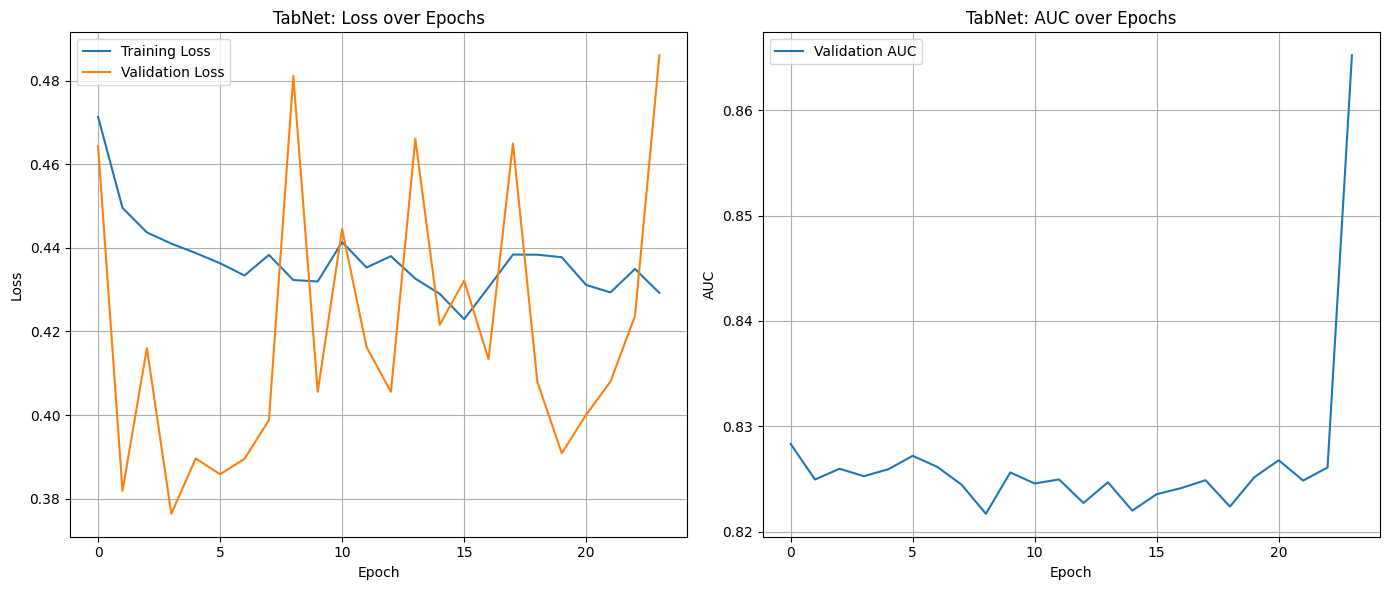

In [ ]:
history = tabnet_model.history

epochs = range(len(history['loss']))

plt.figure(figsize=(14, 6))


plt.subplot(1, 2, 1)
plt.plot(epochs, history['loss'], label='Training Loss')
plt.plot(epochs, history['val_0_logloss'], label='Validation Loss')
plt.title('TabNet: Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(epochs, history['val_0_auc'], label='Validation AUC')
plt.title('TabNet: AUC over Epochs')
plt.xlabel('Epoch')
plt.ylabel('AUC')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

##### MLflow логирование

In [ ]:
params = {
    "architecture": "TabNetClassifier",
    "cat_idxs": str(cat_idxs),
    "cat_dims": str(cat_dims),
    "cat_emb_dim": 1,
    "optimizer": "Adam",
    "learning_rate": 2e-2,
    "scheduler": "StepLR",
    "scheduler_step_size": 50,
    "scheduler_gamma": 0.9,
    "mask_type": "sparsemax",
    "n_d": 8,
    "n_a": 8,
    "n_steps": 3,
    "gamma": 1.3,
    "n_independent": 2,
    "n_shared": 2,
    "max_epochs": 100,
    "patience": 20,
    "batch_size": 1024,
    "virtual_batch_size": 128,
    "class_weights": str(class_weights_tabnet),
    "threshold": 0.5,
    "seed": 42,
}

with mlflow.start_run(experiment_id=exp_id, run_name="Model #10. TabNet"):
    print("Artifact URI for this run:", mlflow.get_artifact_uri())

    y_true = np.asarray(y_test_raw).reshape(-1).astype(int)
    y_pred = np.asarray(y_pred_tabnet).reshape(-1).astype(int)
    proba = np.asarray(y_pred_proba_tabnet).reshape(-1)

    metrics = {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, pos_label=1, zero_division=0),
        "recall": recall_score(y_true, y_pred, pos_label=1, zero_division=0),
        "f1_score": f1_score(y_true, y_pred, pos_label=1, zero_division=0),
        "f2_score": fbeta_score(y_true, y_pred, pos_label=1, beta=2, zero_division=0),
        "roc_auc": roc_auc_score(y_true, proba),
        "pr_auc": average_precision_score(y_true, proba),
    }

    conf_matrix = confusion_matrix(y_true, y_pred)

    fig, ax = plt.subplots(figsize=(6, 4))
    sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", ax=ax)
    ax.set_xlabel("Предсказано")
    ax.set_ylabel("Истинно")
    ax.set_title("Матрица ошибок")
    plt.tight_layout()

    mlflow.log_figure(fig, "confusion_matrix.png")
    plt.close(fig)

    report = classification_report(y_true, y_pred, zero_division=0)

    mlflow.log_text(report, "classification_report.txt")

    print("\nМатрица Ошибок")
    print(conf_matrix)

    print("\nОтчет по Классификации")
    print(report)

    history_epochs = range(len(history["loss"]))

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    axes[0].plot(history_epochs, history["loss"], label="Training Loss")
    axes[0].plot(history_epochs, history["val_0_logloss"], label="Validation Loss")
    axes[0].set_title("TabNet: Loss over Epochs")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].legend()
    axes[0].grid(True)

    axes[1].plot(history_epochs, history["val_0_auc"], label="Validation AUC")
    axes[1].set_title("TabNet: AUC over Epochs")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("AUC")
    axes[1].legend()
    axes[1].grid(True)
    plt.tight_layout()

    mlflow.log_figure(fig, "training_curves.png")
    plt.close(fig)

    mlflow.log_params(params)
    mlflow.log_metrics(metrics)

    for epoch_idx, (train_loss, val_logloss, val_auc) in enumerate(
        zip(history["loss"], history["val_0_logloss"], history["val_0_auc"]),
        start=1,
    ):
        mlflow.log_metric("train_loss", train_loss, step=epoch_idx)
        mlflow.log_metric("val_logloss", val_logloss, step=epoch_idx)
        mlflow.log_metric("val_auc", val_auc, step=epoch_idx)

    signature = infer_signature(X_test_tabnet, tabnet_model.predict_proba(X_test_tabnet))

    model_info = mlflow.sklearn.log_model(
        sk_model=tabnet_model,
        artifact_path="model",
        signature=signature,
        registered_model_name=registered_model_name,
    )

    mlflow.log_input(
        mlflow.data.from_pandas(df, source="../data/raw/Fraud.csv"),
        context="training",
    )

    client = MlflowClient()
    new_version = model_info.registered_model_version

    client.set_model_version_tag(
        registered_model_name,
        new_version,
        "env",
        "training",
    )

    client.set_registered_model_alias(
        registered_model_name,
        "training",
        new_version,
    )

    run_id = mlflow.active_run().info.run_id

    print("Run ID:", run_id)
    print("Registered model version:", new_version)
    print("Alias 'training' points to version:", new_version)
    print("Metrics:", metrics)

после 20 эпох обучения TABNET не показала высоких результатов для определения фродовых операций. "Легальные" операции дали высокие метрики, но наша цель не они

# Итоги

In [1]:
results = []

results.append({
    'Модель': 'Логистическая Регрессия (без балансировки)',
    'Архитектура': 'Линейная модель',
    'Гиперпараметры': 'solver=\'saga\', max_iter=2000',
    'Precision (Class 1)': 0.68,
    'Recall (Class 1)': 0.33,
    'F1-Score (Class 1)': 0.45,
    'Accuracy': 0.86,
    'PR-AUC': '-',
    'Время обучения': 'несколько секунд'
})

results.append({
    'Модель': 'Логистическая Регрессия (с балансировкой)',
    'Архитектура': 'Линейная модель',
    'Гиперпараметры': 'class_weight=\'balanced\', solver=\'saga\', max_iter=2000',
    'Precision (Class 1)': 0.32,
    'Recall (Class 1)': 0.93,
    'F1-Score (Class 1)': 0.47,
    'Accuracy': 0.65,
    'PR-AUC': '-',
    'Время обучения': 'несколько секунд'
})

results.append({
    'Модель': 'Дерево Решений (без балансировки)',
    'Архитектура': 'CART',
    'Гиперпараметры': 'max_depth=5, min_samples_split=20, min_samples_leaf=10',
    'Precision (Class 1)': 0.74,
    'Recall (Class 1)': 0.33,
    'F1-Score (Class 1)': 0.46,
    'Accuracy': 0.87,
    'PR-AUC': '-',
    'Время обучения': 'несколько секунд'
})


results.append({
    'Модель': 'Дерево Решений (с балансировкой)',
    'Архитектура': 'CART',
    'Гиперпараметры': 'max_depth=15, min_samples_split=20, min_samples_leaf=10, class_weight=\'balanced\'',
    'Precision (Class 1)': 0.39,
    'Recall (Class 1)': 0.92,
    'F1-Score (Class 1)': 0.55,
    'Accuracy': 0.75,
    'PR-AUC': '-',
    'Время обучения': 'несколько секунд'
})


results.append({
    'Модель': 'Случайный Лес',
    'Архитектура': 'Ансамбль деревьев решений',
    'Гиперпараметры': 'n_estimators=100, max_depth=20',
    'Precision (Class 1)': 0.74,
    'Recall (Class 1)': 0.32,
    'F1-Score (Class 1)': 0.45,
    'Accuracy': 0.87,
    'PR-AUC': '-',
    'Время обучения': 'Несколько минут'
})


results.append({
    'Модель': 'CatBoost (без балансировки)',
    'Архитектура': 'Градиентный бустинг на деревьях решений',
    'Гиперпараметры': 'random_state=42',
    'Precision (Class 1)': 0.74,
    'Recall (Class 1)': 0.33,
    'F1-Score (Class 1)': 0.46,
    'Accuracy': 0.87,
    'PR-AUC': '-',
    'Время обучения': '~ 4 мин'
})


results.append({
    'Модель': 'CatBoost (с балансировкой)',
    'Архитектура': 'Градиентный бустинг на деревьях решений',
    'Гиперпараметры': 'auto_class_weights=\'Balanced\'',
    'Precision (Class 1)': 0.39,
    'Recall (Class 1)': 0.92,
    'F1-Score (Class 1)': 0.55,
    'Accuracy': 0.75,
    'PR-AUC': '-',
    'Время обучения': '~ 4 мин'
})


results.append({
    'Модель': 'CatBoost (с балансировкой, нативные кат. признаки)',
    'Архитектура': 'Градиентный бустинг на деревьях решений',
    'Гиперпараметры': 'auto_class_weights=\'Balanced\', cat_features=[...]',
    'Precision (Class 1)': 0.39,
    'Recall (Class 1)': 0.92,
    'F1-Score (Class 1)': 0.55,
    'Accuracy': 0.75,
    'PR-AUC': '-',
    'Время обучения': '~20 мин'
})


results.append({
    'Модель': 'Дерево Решений (Optuna, Poly Features)',
    'Архитектура': 'CART с полиномиальными признаками',
    'Гиперпараметры': 'max_depth=8, min_samples_leaf=2, min_samples_split=5, class_weight=\'balanced\'',
    'Precision (Class 1)': 0.39,
    'Recall (Class 1)': 0.93,
    'F1-Score (Class 1)': 0.55,
    'Accuracy': 0.75,
    'PR-AUC': '-',
    'Время обучения': '~1 час 30 мин (с учетом Optuna)'
})


results.append({
    'Модель': 'Нейронная сеть (Базовая)',
    'Архитектура': '4-слойная полносвязная NN (512-256-128-64)',
    'Гиперпараметры': 'Batchnorm, Dropout, pos_weight, LR=0.0005, Adam, 10 эпох',
    'Precision (Class 1)': 0.35,
    'Recall (Class 1)': 0.91,
    'F1-Score (Class 1)': 0.50,
    'Accuracy': 0.70,
    'PR-AUC': 0.5234,
    'Время обучения': '~7 мин'
})


results.append({
    'Модель': 'Нейронная сеть (с регуляризацией)',
    'Архитектура': '4-слойная полносвязная NN (512-256-128-64)',
    'Гиперпараметры': 'Batchnorm, Dropout, pos_weight, LR=0.0005, Adam, weight_decay=1e-4, 10 эпох',
    'Precision (Class 1)': 0.35,
    'Recall (Class 1)': 0.91,
    'F1-Score (Class 1)': 0.50,
    'Accuracy': 0.70,
    'PR-AUC': '-',
    'Время обучения': '~7 мин'
})


results.append({
    'Модель': 'Нейронная сеть (Optuna)',
    'Архитектура': '3-слойная полносвязная NN (192-320-256)',
    'Гиперпараметры': 'LR=0.000255, weight_decay=2.28e-05, dropout=[0.2, 0.1, 0.2], 20 эпох',
    'Precision (Class 1)': 0.36,
    'Recall (Class 1)': 0.86,
    'F1-Score (Class 1)': 0.51,
    'Accuracy': 0.72,
    'PR-AUC': 0.4726,
    'Время обучения': '~1 час 10 мин (с учетом Optuna)'
})


results.append({
    'Модель': 'Нейронная сеть (Attention-based)',
    'Архитектура': 'NN с механизмом Self-Attention',
    'Гиперпараметры': 'LR=0.000255, weight_decay=2.28e-05, dropout=[0.2, 0.1, 0.2], 20 эпох, 4 головы внимания',
    'Precision (Class 1)': 0.35,
    'Recall (Class 1)': 0.89,
    'F1-Score (Class 1)': 0.51,
    'Accuracy': 0.71,
    'PR-AUC': 0.4641,
    'Время обучения': '~15 мин'
})


results.append({
    'Модель': 'TabNet',
    'Архитектура': 'Tabular Deep Learning с sparsemax attention',
    'Гиперпараметры': 'cat_emb_dim=1, optimizer_params=dict(lr=2e-2), n_d=8, n_a=8, n_steps=3, gamma=1.3, n_independent=2, n_shared=2, max_epochs=100 (early stopping на 23-й)',
    'Precision (Class 1)': 0.68,
    'Recall (Class 1)': 0.33,
    'F1-Score (Class 1)': 0.45,
    'Accuracy': 0.86,
    'PR-AUC': 0.4689,
    'Время обучения': '~15 мин'
})

df_results = pd.DataFrame(results)
df_results.set_index('Модель', inplace=True)

display(df_results.style.set_caption('Сводная таблица результатов экспериментов'))


,Архитектура,Гиперпараметры,Precision (Class 1),Recall (Class 1),F1-Score (Class 1),Accuracy,PR-AUC,Время обучения
Модель,,,,,,,,
Логистическая Регрессия (без балансировки),Линейная модель,"solver='saga', max_iter=2000",0.680000,0.330000,0.450000,0.860000,-,несколько секунд
Логистическая Регрессия (с балансировкой),Линейная модель,"class_weight='balanced', solver='saga', max_iter=2000",0.320000,0.930000,0.470000,0.650000,-,несколько секунд
Дерево Решений (без балансировки),CART,"max_depth=5, min_samples_split=20, min_samples_leaf=10",0.740000,0.330000,0.460000,0.870000,-,несколько секунд
Дерево Решений (с балансировкой),CART,"max_depth=15, min_samples_split=20, min_samples_leaf=10, class_weight='balanced'",0.390000,0.920000,0.550000,0.750000,-,несколько секунд
Случайный Лес,Ансамбль деревьев решений,"n_estimators=100, max_depth=20",0.740000,0.320000,0.450000,0.870000,-,Несколько минут
CatBoost (без балансировки),Градиентный бустинг на деревьях решений,random_state=42,0.740000,0.330000,0.460000,0.870000,-,~ 4 мин
CatBoost (с балансировкой),Градиентный бустинг на деревьях решений,auto_class_weights='Balanced',0.390000,0.920000,0.550000,0.750000,-,~ 4 мин
"CatBoost (с балансировкой, нативные кат. признаки)",Градиентный бустинг на деревьях решений,"auto_class_weights='Balanced', cat_features=[...]",0.390000,0.920000,0.550000,0.750000,-,~20 мин
"Дерево Решений (Optuna, Poly Features)",CART с полиномиальными признаками,"max_depth=8, min_samples_leaf=2, min_samples_split=5, class_weight='balanced'",0.390000,0.930000,0.550000,0.750000,-,~1 час 30 мин (с учетом Optuna)


### **Анализ результатов и выводы**

#### **Лучшее решение среди DL моделей**

Среди представленных DL моделей первая по порядку 4-слойная полносвязная нейронная сеть с использованием балансировки классов, dropout и batchnorm показала наилучшие результаты:  
*   Recall (Class 1): 0.91  
*   Precision (Class 1): 0.35  
*   F1-Score (Class 1): 0.50
*   PR-AUC: 0.5234

#### **Почему одна DL архитектура оказалась лучше другой?**

1.  **Нейронная сеть (Базовая) vs (с регуляризацией):** Базовая нейронная сеть продемонстрировала нестабильное обучение, что может свидетельствовать о переобучении или неспособности сети эффективно обрабатывать несбалансированные данные. Добавление регуляризации немного стабилизировало обучение, но не улучшило Recall, а для  Class 0 даже понизило с 0.66 до 0.65.
2.  **Нейронная сеть (с регуляризацией) vs Optuna:** Дальнейшая оптимизация гиперпараметров с помощью Optuna (количество слоев, нейронов в слоях, скорости отсева, скорость обучения, коэффициент L2-регуляризации) привела к небольшому улучшению F1-Score с 0.50 до 0.51 на Class 1 при одновременном снижении  Recall до 0.86.
3.  **Нейронная сеть Attention-based:** Эта модель показала немного худшие результаты - Recall: 0.89, F1: 0.51, PR-AUC: 0.4641 по сравнению с обычными полносвязными сетями. Это может быть связано с тем, что для текущего набора данных сложность механизма внимания не дала значительных преимуществ или требовала более тонкой настройки. Возможно, это связано с небольшим количеством фичей и отстутствием цепочек действий по отдельным клиентам в датасете.
4.  **TabNet:** Эта модель, специально разработанная для табличных данных, показала самые низкие результаты по Recall 0.33 среди всех DL-моделей. Это неожиданно, учитывая ее позиционирование. Возможно, конфигурация или механизм работы с категориальными признаками не были оптимальными для специфики нашего несбалансированного набора данных или для метрики Recall, несмотря на попытки балансировки классов через `sample_weights`.

#### **Почему ML оказался лучше DL в вашей задаче?**

При анализе сводной таблицы становится очевидно, что традиционные ML модели, такие как Дерево Решений (Optuna, Poly Features) и CatBoost с балансировкой, превзошли Deep Learning решения по ключевым метрикам.


Это указывает на несколько важных аспектов:

1.  **Природа данных:** Наши данные являются табличными и, вероятно, не обладают сложной иерархической или пространственной структурой, которая является сильной стороной глубоких нейронных сетей. Для табличных данных, где признаки часто имеют более явные и интерпретируемые отношения, бустинговые деревья решений и даже логистическая регрессия могут быть очень эффективными.
2.  **Сложность признаков:** Эффективная предварительная обработка данных, включая `one-hot encoding`, `StandardScaler` и `Target Encoding` для признака `City`, а также создание полиномиальных признаков, вероятно, извлекла достаточно информации из исходных данных. Это позволило более простым ML-моделям легко найти закономерности, не требуя сложной многослойной архитектуры для извлечения абстрактных признаков.
3.  **Несбалансированность классов:** Задача обнаружения мошенничества является сильно несбалансированной. Хотя мы применяли взвешивание классов и для DL, и для ML моделей, древовидные ансамбли часто демонстрируют высокую устойчивость к таким проблемам, особенно при правильной настройке и балансировке. Более того, деревья решений способны эффективно работать с категориальными и числовыми признаками одновременно, а CatBoost имеет встроенные механизмы для работы с категориальными признаками, что упрощает пайплайн и повышает производительность.
4.  **Размер и сложность:** Несмотря на большой объем данных, они не являются настолько сложными, чтобы требовать глубоких иерархических структур, которые эффективно извлекают DL-модели. В случаях с более простыми структурами данных и относительно небольшим количеством признаков, ML-модели часто достигают конкурентоспособных или даже лучших результатов, поскольку они менее подвержены переобучению и требуют меньше данных для обучения. Таким образом, для данной задачи, традиционные ML-подходы оказались более подходящими и эффективными.